# **APS1: EDA**

Membros do projeto: Luiz Miguel e Lucas Kenji

Entrega: 15 Marco, 2026

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score
from scipy.stats.mstats import winsorize

## 1. **Carregamento e inspeção inicial dos dados**

### **Carregamento e analise dos datasets:**
- Conjunto de treino: `adult.data`

In [27]:
# Carregando o dataset adult.data
df_train = pd.read_csv('dataset/adult.data', header=None)
df_train.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
              'marital-status', 'occupation', 'relationship', 'race', 'sex',
              'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
              'income']
df_train.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


- Conjunto de teste: `adult.test`

In [28]:
# Carregando o dataset adult.test
df_test = pd.read_csv('dataset/adult.test', header=None, skiprows=1)
df_test.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
              'marital-status', 'occupation', 'relationship', 'race', 'sex',
              'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
              'income']
# df_test.head()

### **Explicando cada feature e identificando os tipos de dados do dataset**

In [29]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


- `age`:    **Idade do indivíduo** (contínua);
- `workclass`:  **Categoria do trabalho** (categórica);
- `fnlwgt`:     **Peso final** (contínua);
- `education`:  **Nível de escolaridade** (categórica);
- `education-num`:  **Nível de escolaridade em grau** (contínua);
- `marital-status`:     **Estado civil** (categórica);
- `occupation`:     **Ocupação profissional** (categórica);
- `relationship`:   **Relacionamento** (categórica);
- `race`:   **Etnia** (categórica);
- `sex`:    **Gênero** (categórica);
- `capital-gain`:   **Ganhos de capital** (contínua);
- `capital-loss`:   **Perdas de capital** (contínua);
- `hours-per-week`:     **Horas de trabalho semanais** (contínua);
- `native-country`:     **País de origem** (categórica);
- `income`:     **Renda anual** (contínua);

### **Verificando o número de instâncias e features**

In [30]:
df_train.shape, df_test.shape

((32561, 15), (16281, 15))

In [31]:
df_train.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='str')

Dentro do dataset de treino possuimos **32561** instâncias e **14** features (e 1 target)

### **Analisando a distruibuicao da target**

<Axes: xlabel='income', ylabel='Count'>

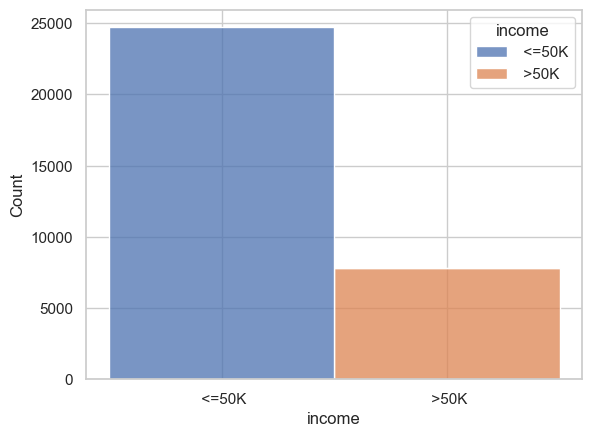

In [32]:
# Histograma da variável alvo 'income' para análise de distribuição
sns.histplot(data=df_train, x='income', hue='income', multiple='stack')

## 2. **Análise univariada**

### **Medidas descritivas para variáveis contínuas.**

In [33]:
# Features numéricas
numericals = ['age', 'fnlwgt', 'capital-gain', 'education-num', 'capital-loss', 'hours-per-week']

# Estatísticas descritivas para variáveis numéricas
df_train[numericals].describe()

,age,fnlwgt,capital-gain,education-num,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,1077.648844,10.080679,87.303830,40.437456
std,13.640433,1.055500e+05,7385.292085,2.572720,402.960219,12.347429
min,17.000000,1.228500e+04,0.000000,1.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,0.000000,9.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,0.000000,10.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,0.000000,12.000000,0.000000,45.000000
max,90.000000,1.484705e+06,99999.000000,16.000000,4356.000000,99.000000


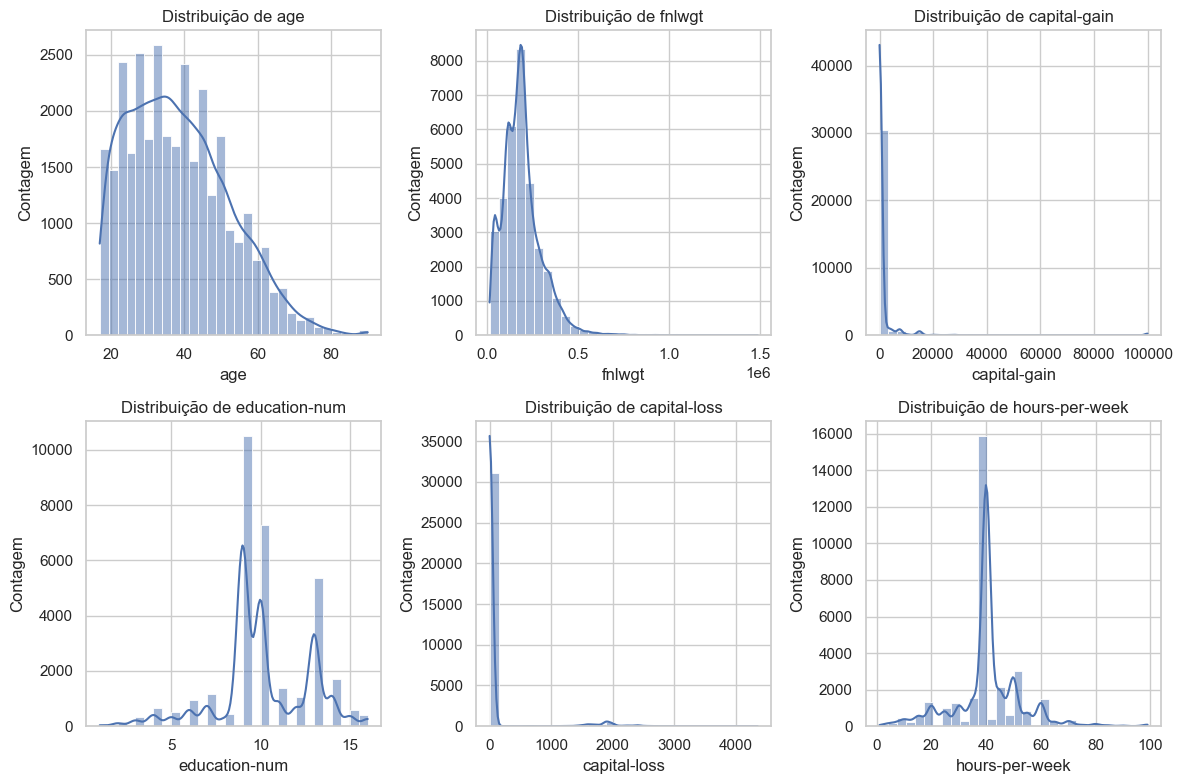

In [34]:
# Histogramas para variáveis numéricas para análise de distribuição
plt.figure(figsize=(12, 8))
for i, col in enumerate(numericals):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df_train[col], kde=True, bins=30)  # bins=30 para melhor granularidade; kde para curva de densidade
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Contagem')
plt.tight_layout()
plt.show()

### **Medidas descritivas para variáveis categóricas.**

       workclass education       marital-status       occupation relationship  \
count      32561     32561                32561            32561        32561   
unique         9        16                    7               15            6   
top      Private   HS-grad   Married-civ-spouse   Prof-specialty      Husband   
freq       22696     10501                14976             4140        13193   

          race    sex  native-country  
count    32561  32561           32561  
unique       5      2              42  
top      White   Male   United-States  
freq     27816  21790           29170  

                                                         Frequency
workclass  education     marital-status      occupation         relationship   race                sex     native-country
Private    HS-grad       Married-civ-spouse  Craft-repair       Husband        White               Male    United-States     803
           Bachelors     Married-civ-spouse  Exec-managerial    Husband    

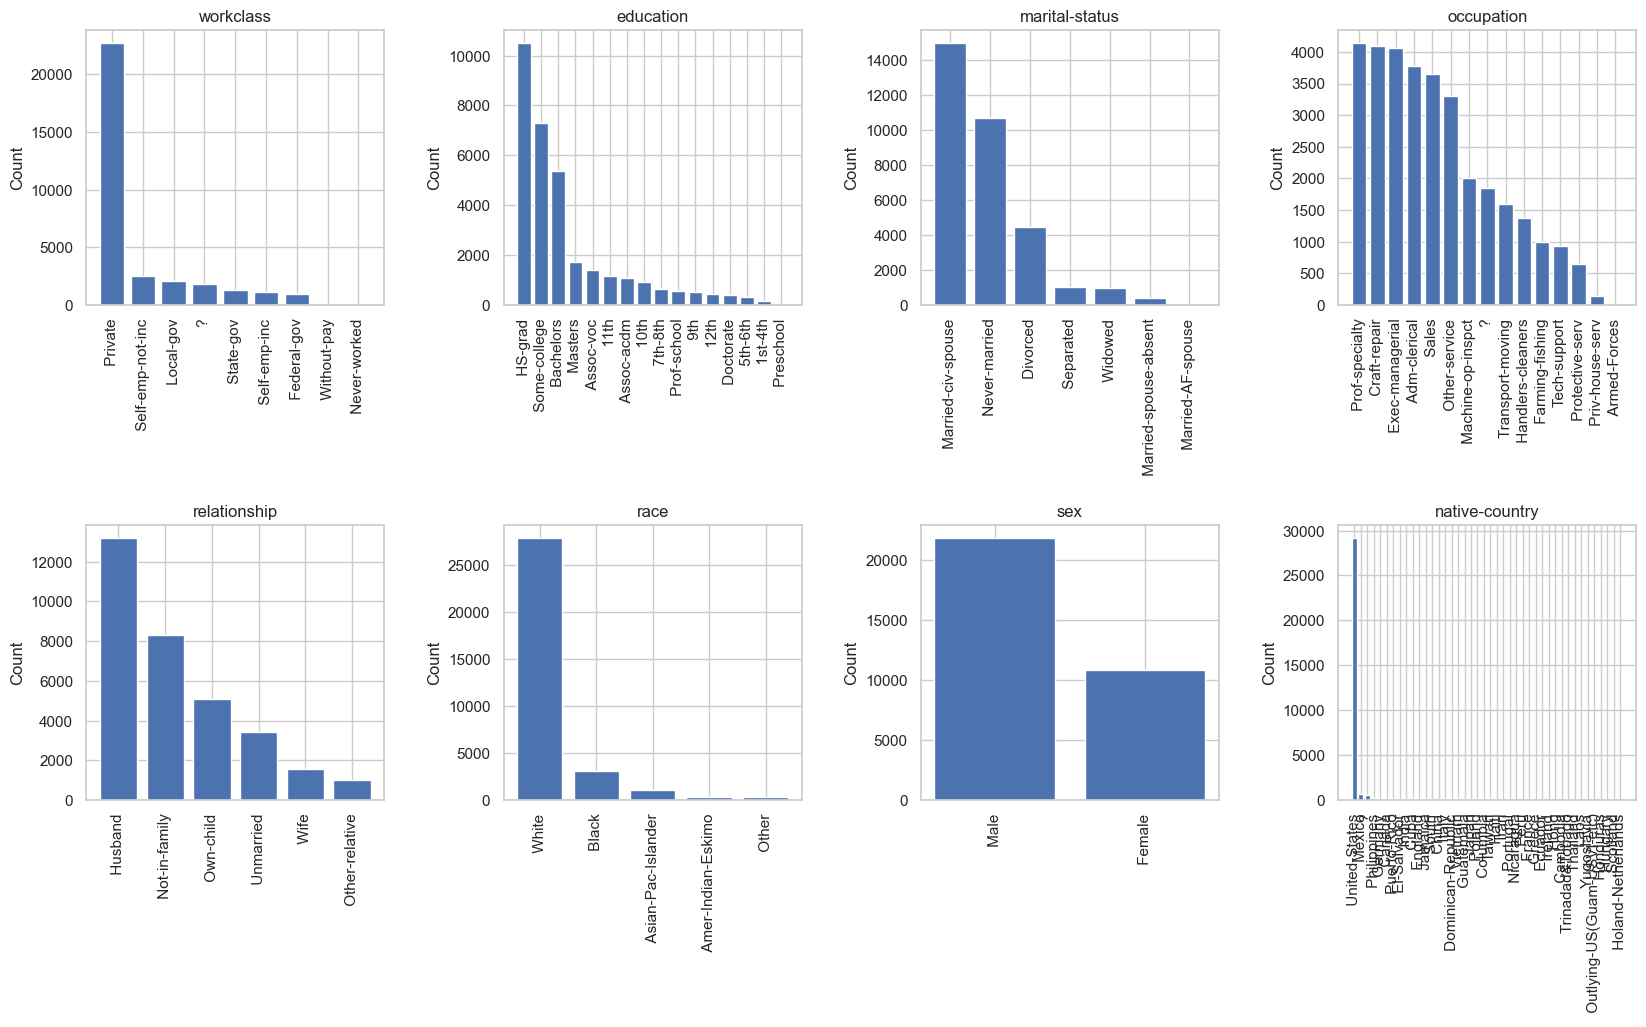

In [35]:
# Features categóricas
categories = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

print("===================================================================================================================================")
print(df_train[categories].describe()) # Estatísticas descritivas para variáveis categóricas
print("\n===================================================================================================================================")
print("                                                         Frequency")
print("===================================================================================================================================")
print(df_train[categories].value_counts()) # Frequências para variáveis categóricas

# Visualização das distribuições das variáveis categóricas
i = 1
plt.figure(figsize=(20, 10))
for col in categories:
    plt.subplot(2, 4, i)
    plt.bar(df_train[col].value_counts().index.astype(str), df_train[col].value_counts().values) # Gráfico de barras para categorias
    plt.ylabel("Count")
    plt.title(col)
    plt.xticks(rotation=90)
    i += 1
plt.subplots_adjust(hspace=0.8, wspace=0.4)
plt.show()

### **Detecção de outliers nas variaveis númericas**

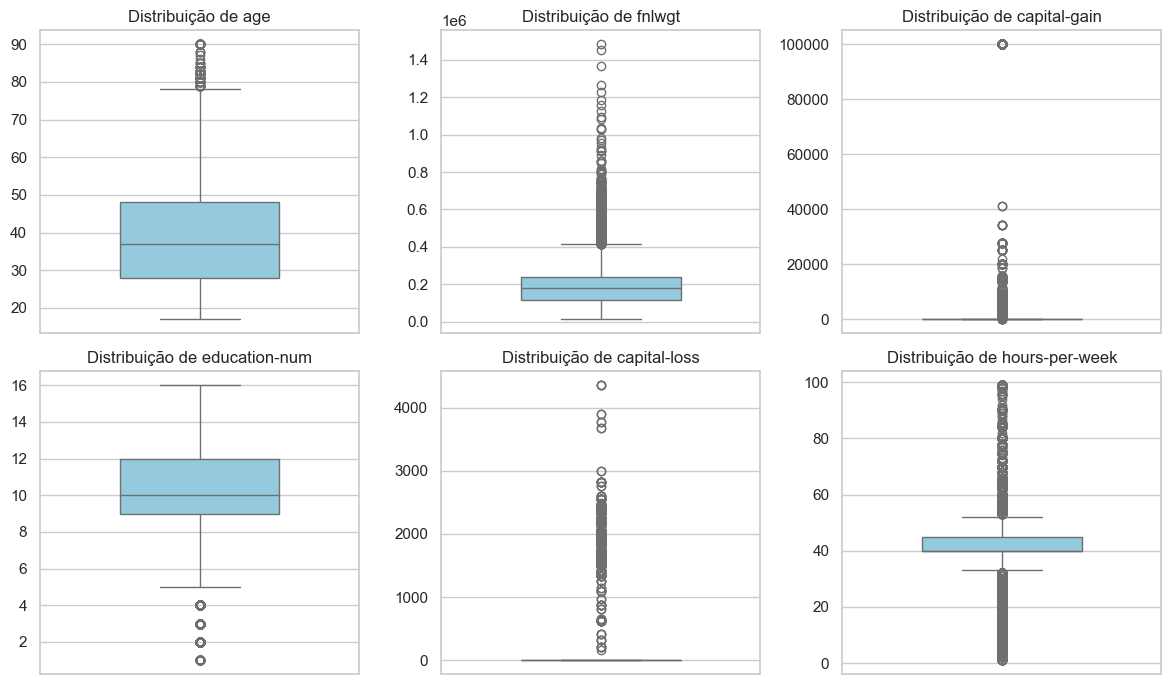

In [36]:
# Definindo o estilo visual
sns.set_theme(style="whitegrid") 

# Criando a figura com o tamanho desejado
plt.figure(figsize=(12, 7))

# Loop para criar um subplot para cada variável numérica
for i, col in enumerate(numericals):
    plt.subplot(2, 3, i + 1) # Ajuste (2, 3) conforme o número de colunas
    sns.boxplot(y=df_train[col], color='skyblue', width=0.5)
    plt.title(f'Distribuição de {col}', fontsize=12)
    plt.ylabel('') # Remove o label repetitivo do eixo Y

# Ajusta o espaçamento entre os gráficos automaticamente
plt.tight_layout()
plt.show()

## 3. **Análise bivariada e multivariada**

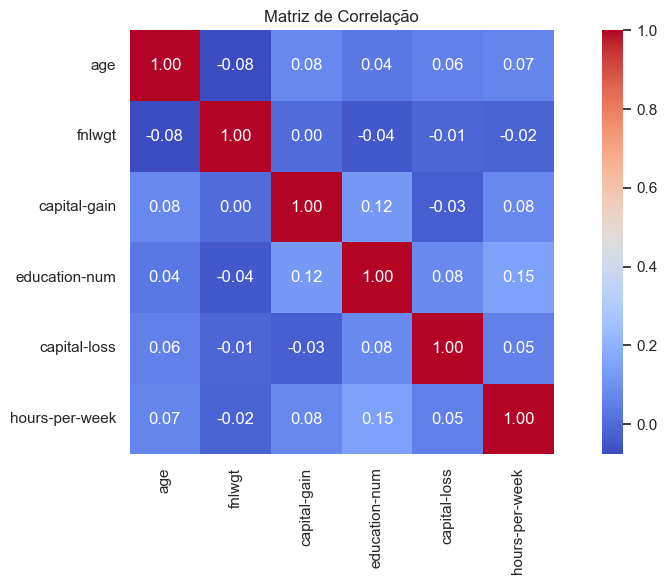

In [37]:
# Criando a matriz de correlação para as variáveis numéricas
corr_matrix = df_train[numericals].corr()

# Plotando o  heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr_matrix, fmt='.2f', square=True, linecolor='white', annot=True, cmap="coolwarm");
plt.title('Matriz de Correlação')
plt.tight_layout()

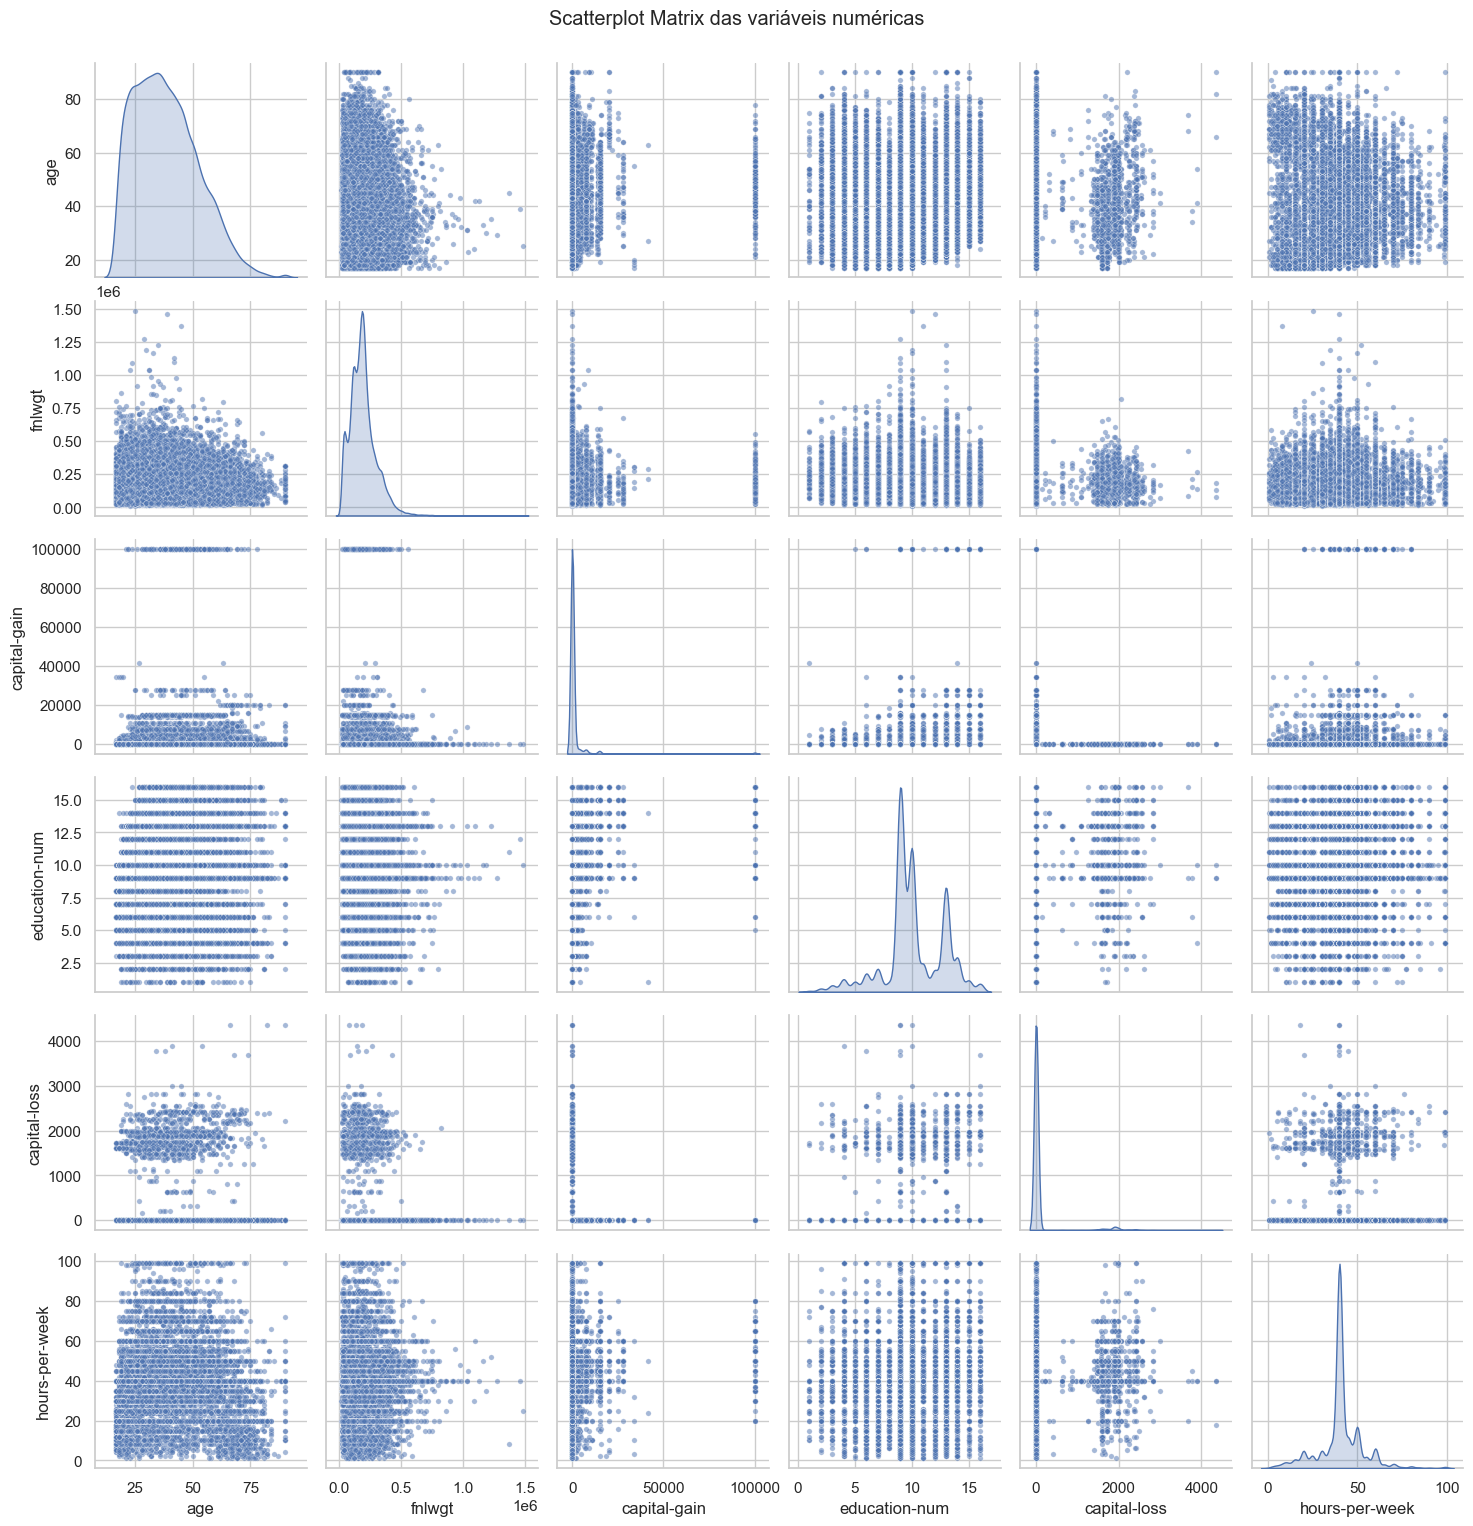

In [38]:
# Scatterplot matrix (Pairplot) das variáveis numéricas para analisar relações pairwise
sns.pairplot(df_train[numericals], kind="scatter", diag_kind="kde", plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle('Scatterplot Matrix das variáveis numéricas', y=1.02)
plt.show()


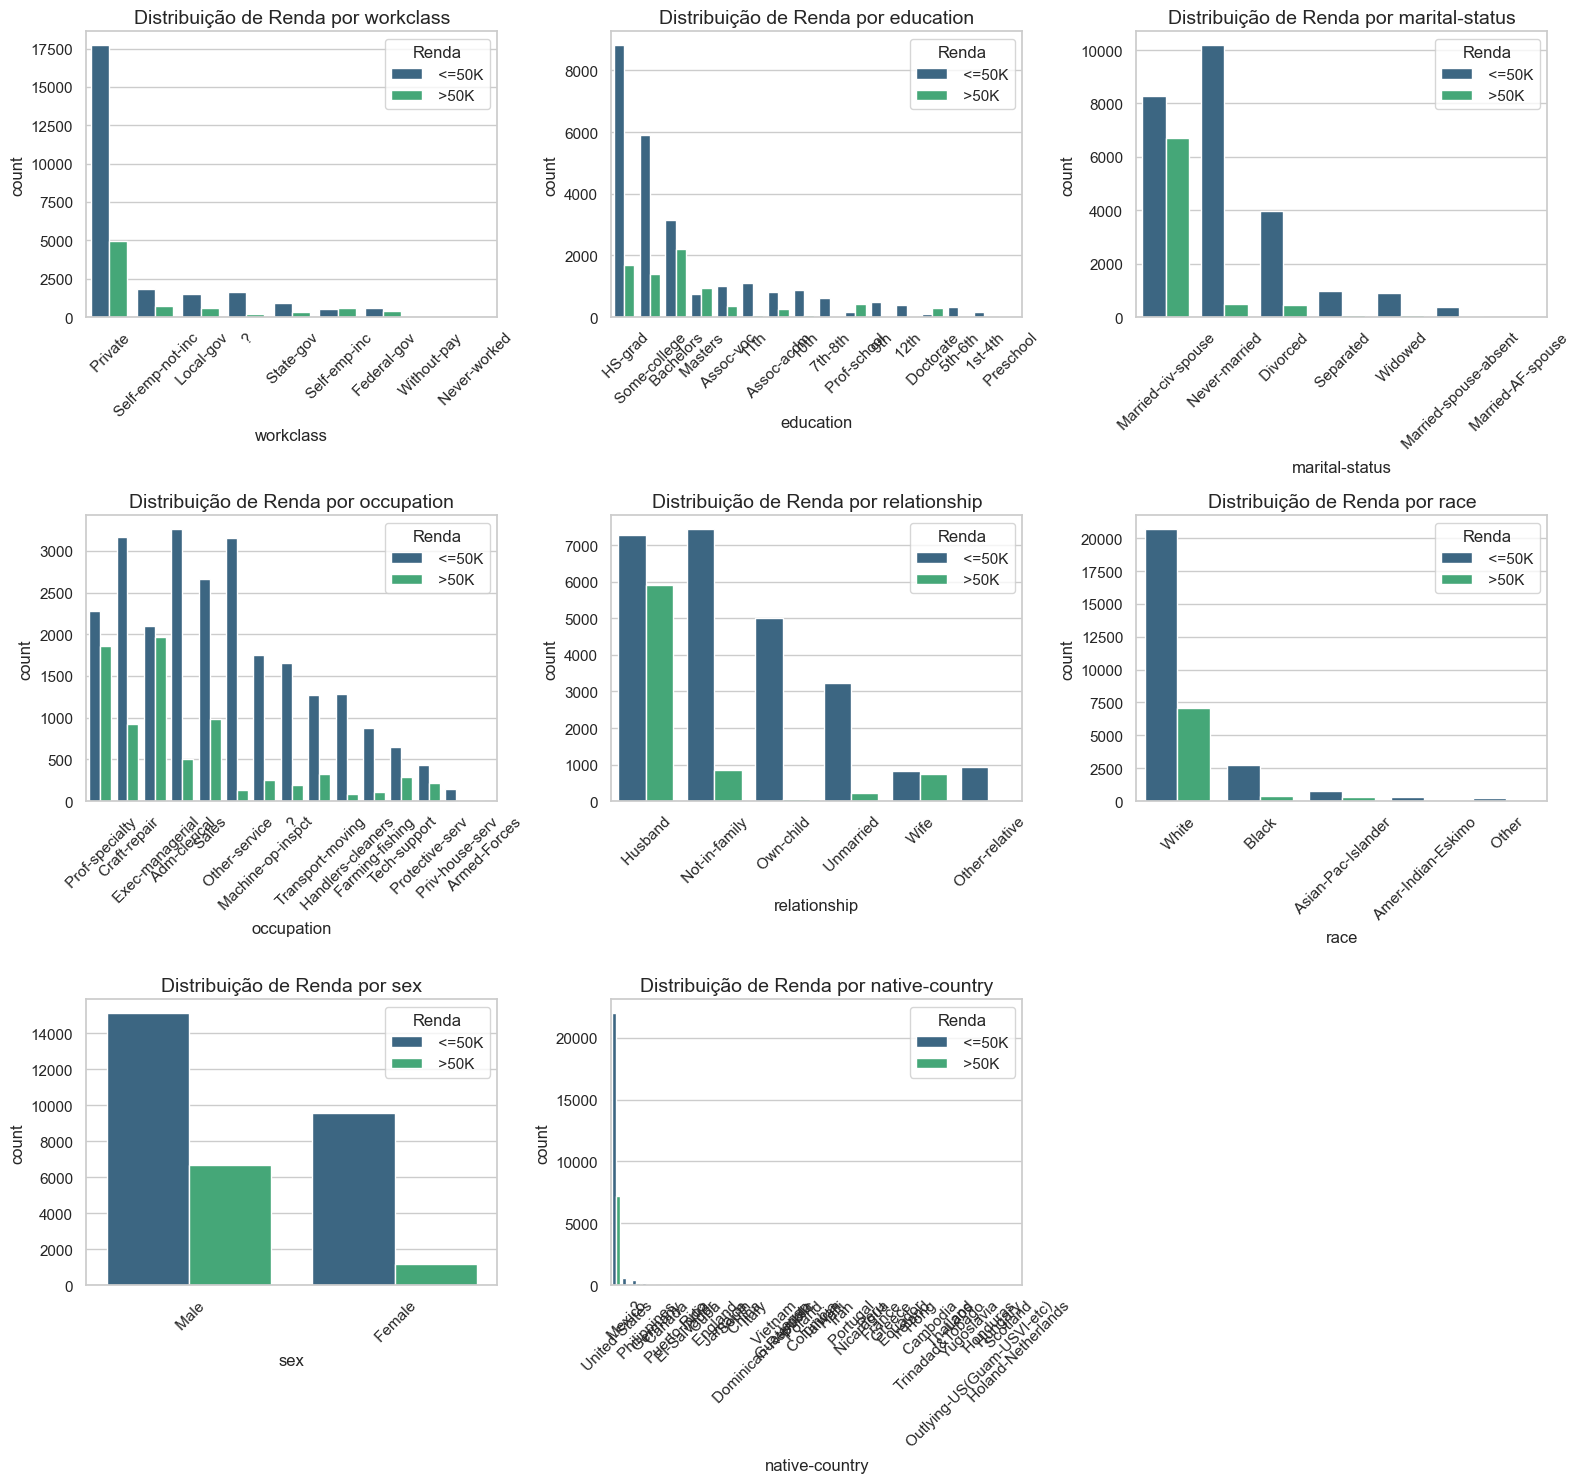

In [39]:
cols = 3 # Número de colunas para os subplots
rows = (len(categories) + cols - 1) // cols 

# Criando os subplots para as variáveis categóricas
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

# Loop para criar um subplot para cada variável categórica, mostrando a distribuição de 'income' para cada categoria
for i, col in enumerate(categories):
    order = df_train[col].value_counts().index
    sns.countplot(data=df_train, x=col, hue='income', ax=axes[i], palette='viridis', order=order)
    
    axes[i].set_title(f'Distribuição de Renda por {col}', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Renda', loc='upper right')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


--- Analisando Distribuição de Variáveis Numéricas por WORKCLASS ---


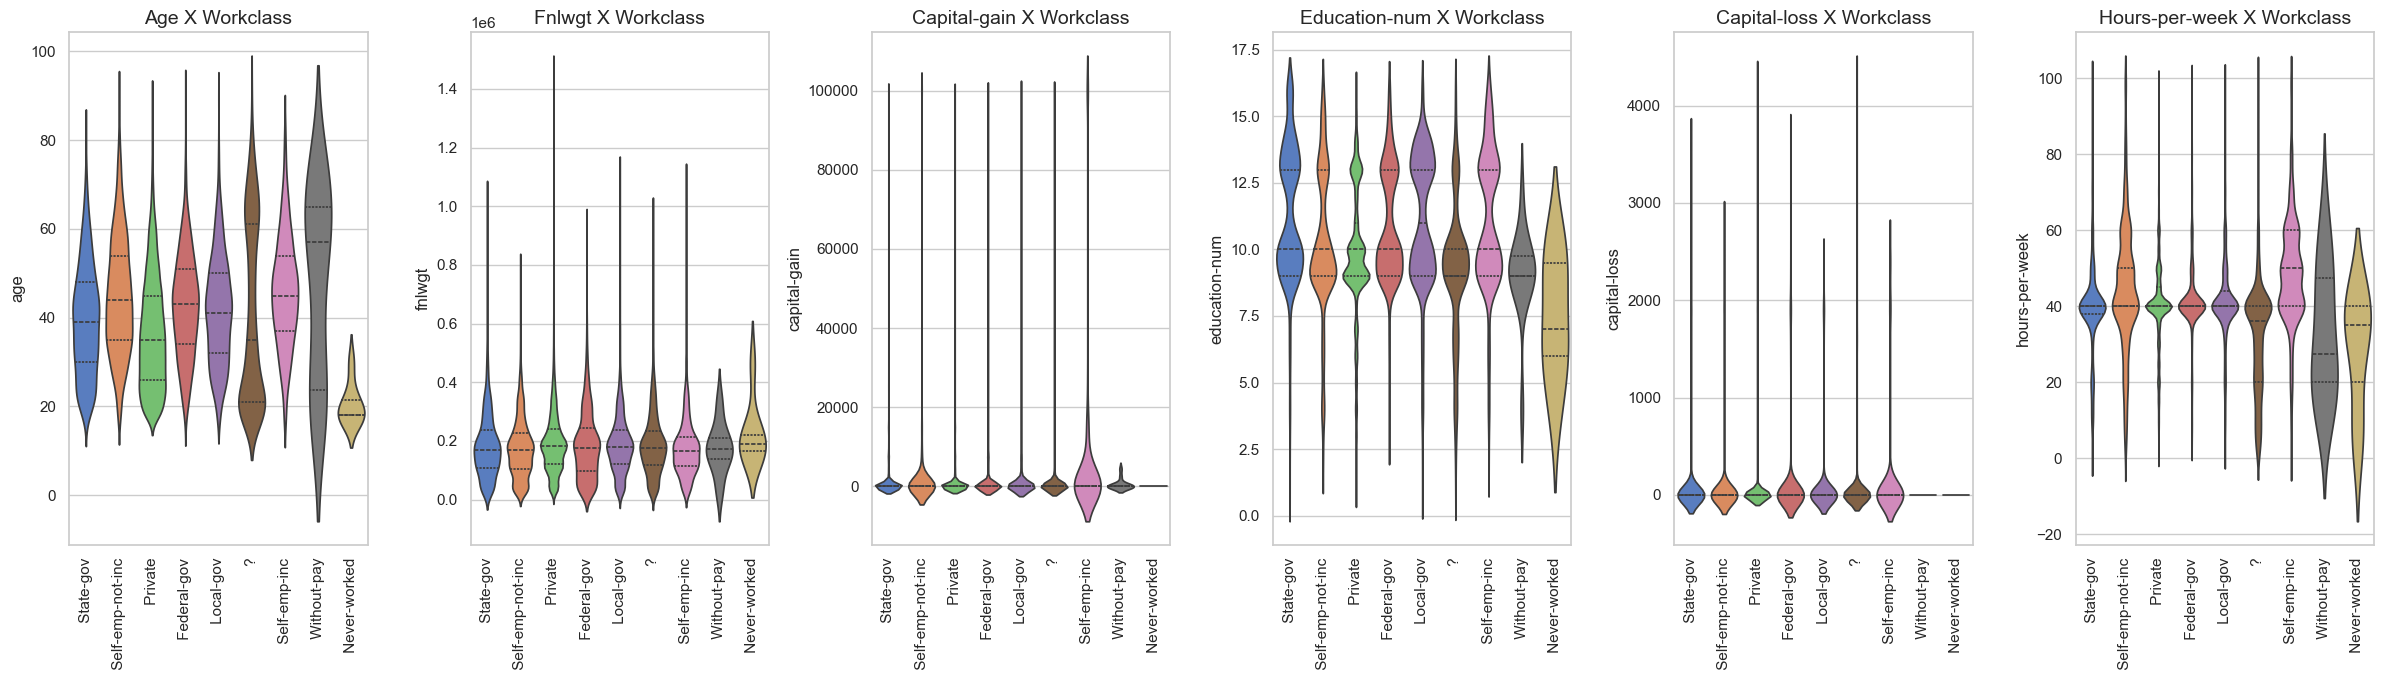


--- Analisando Distribuição de Variáveis Numéricas por EDUCATION ---


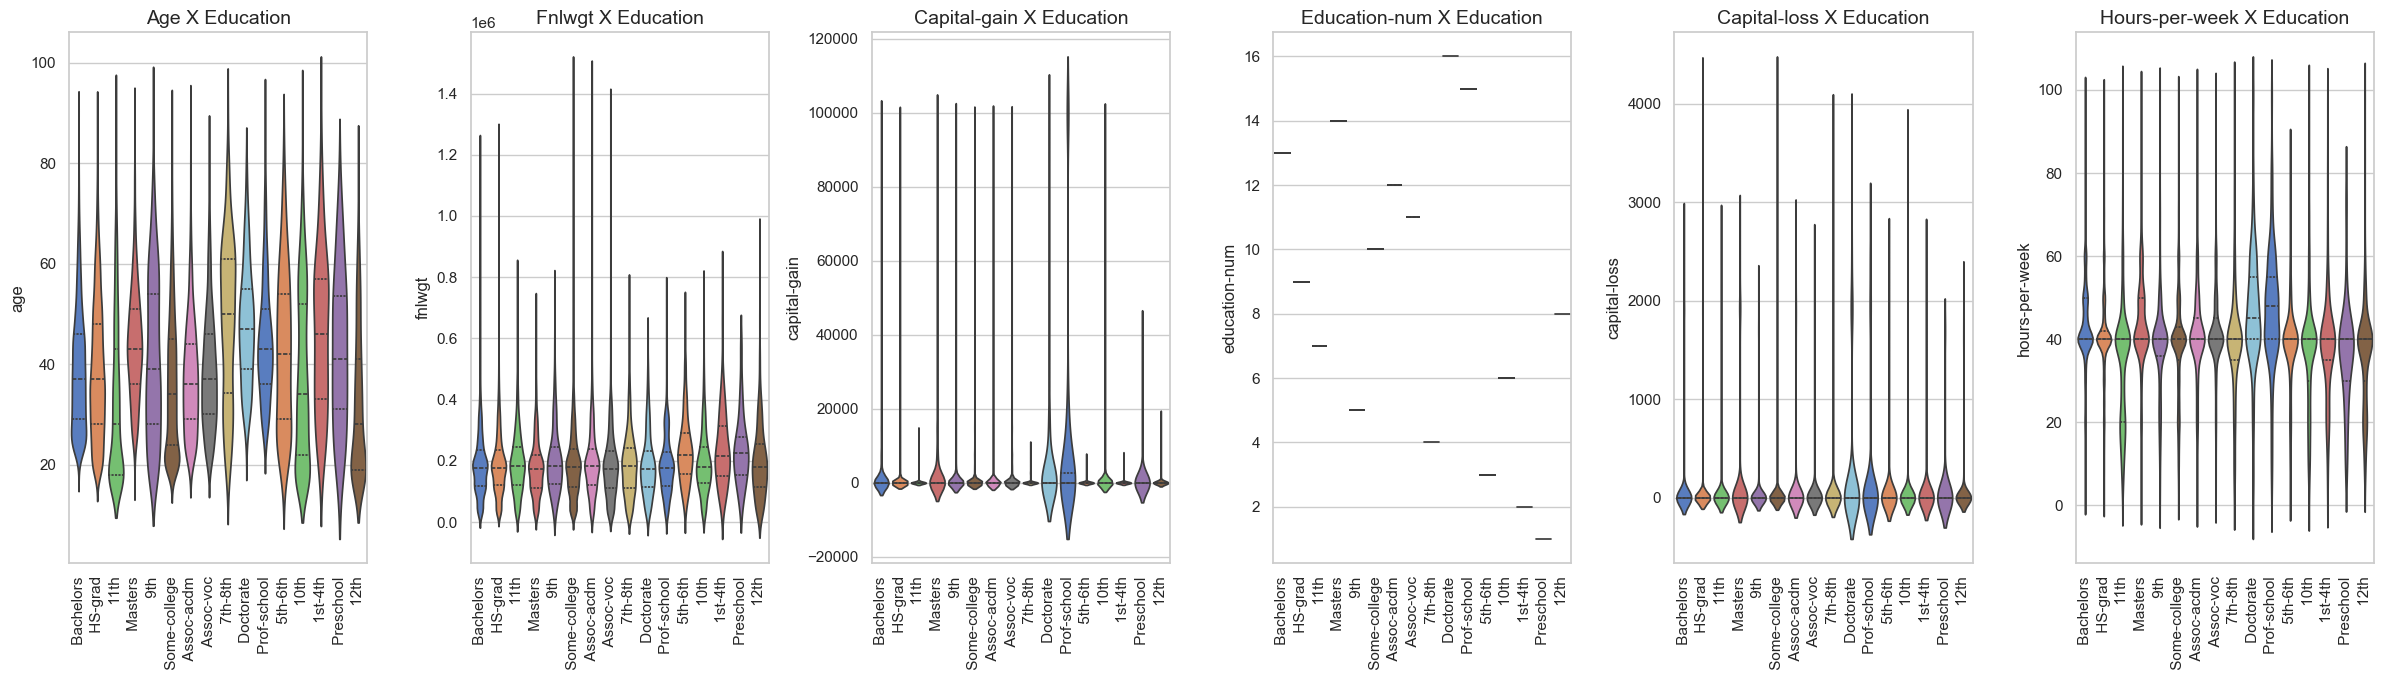


--- Analisando Distribuição de Variáveis Numéricas por MARITAL-STATUS ---


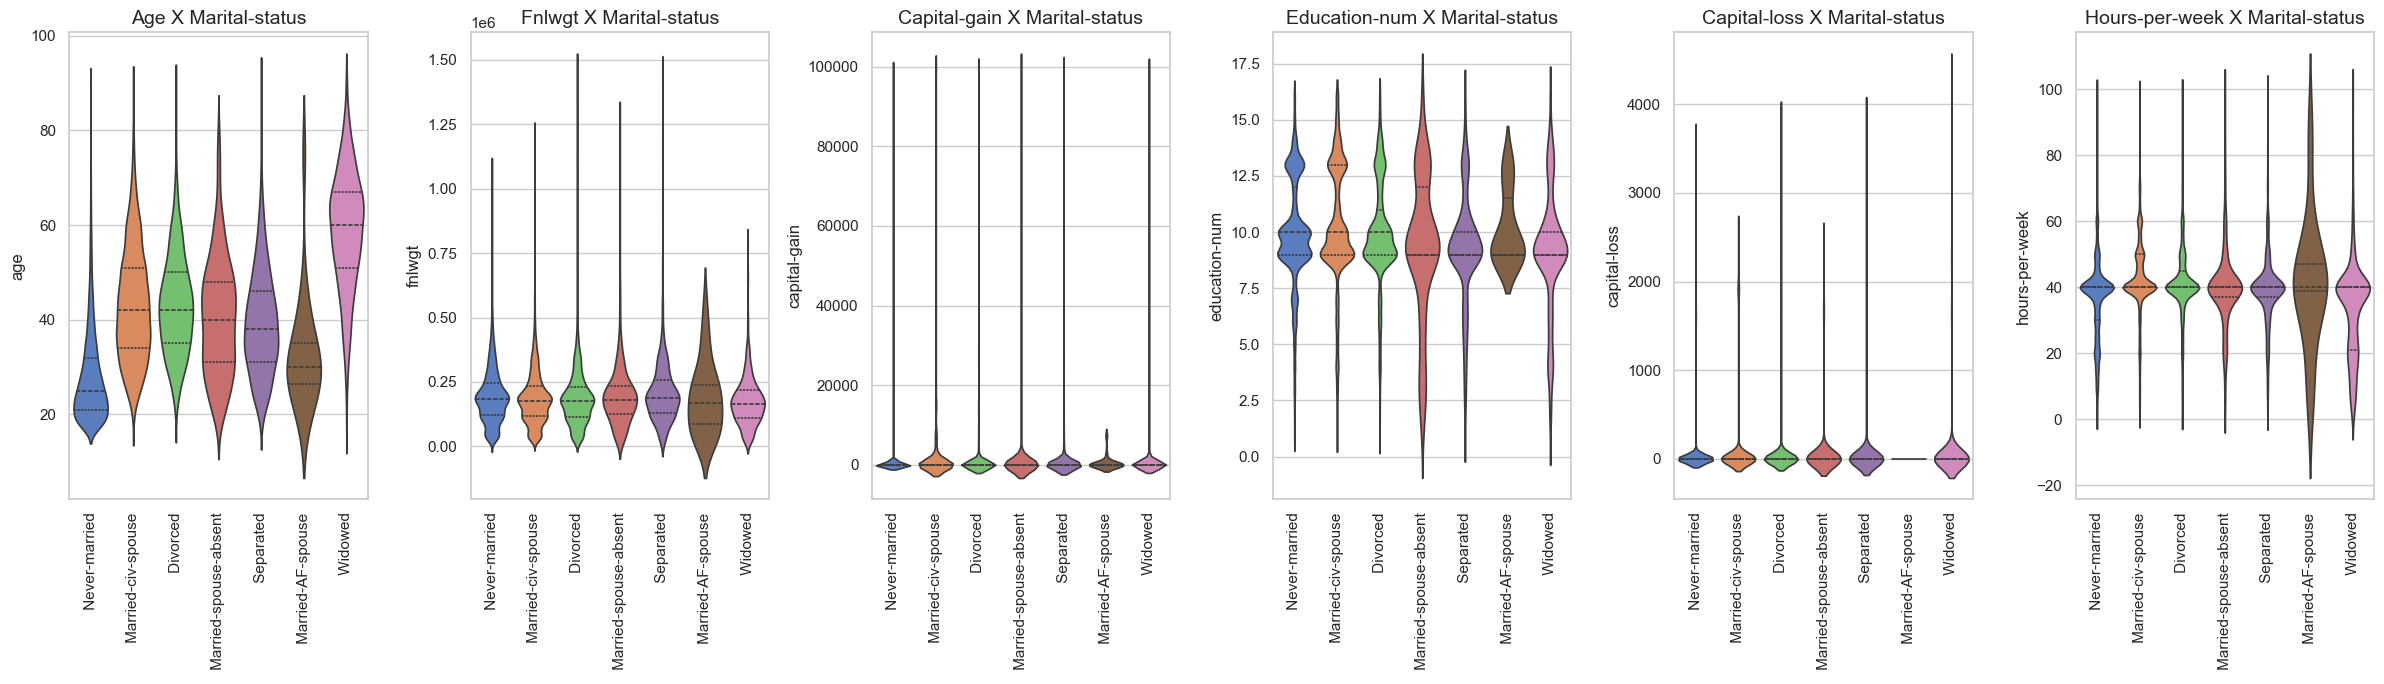


--- Analisando Distribuição de Variáveis Numéricas por OCCUPATION ---


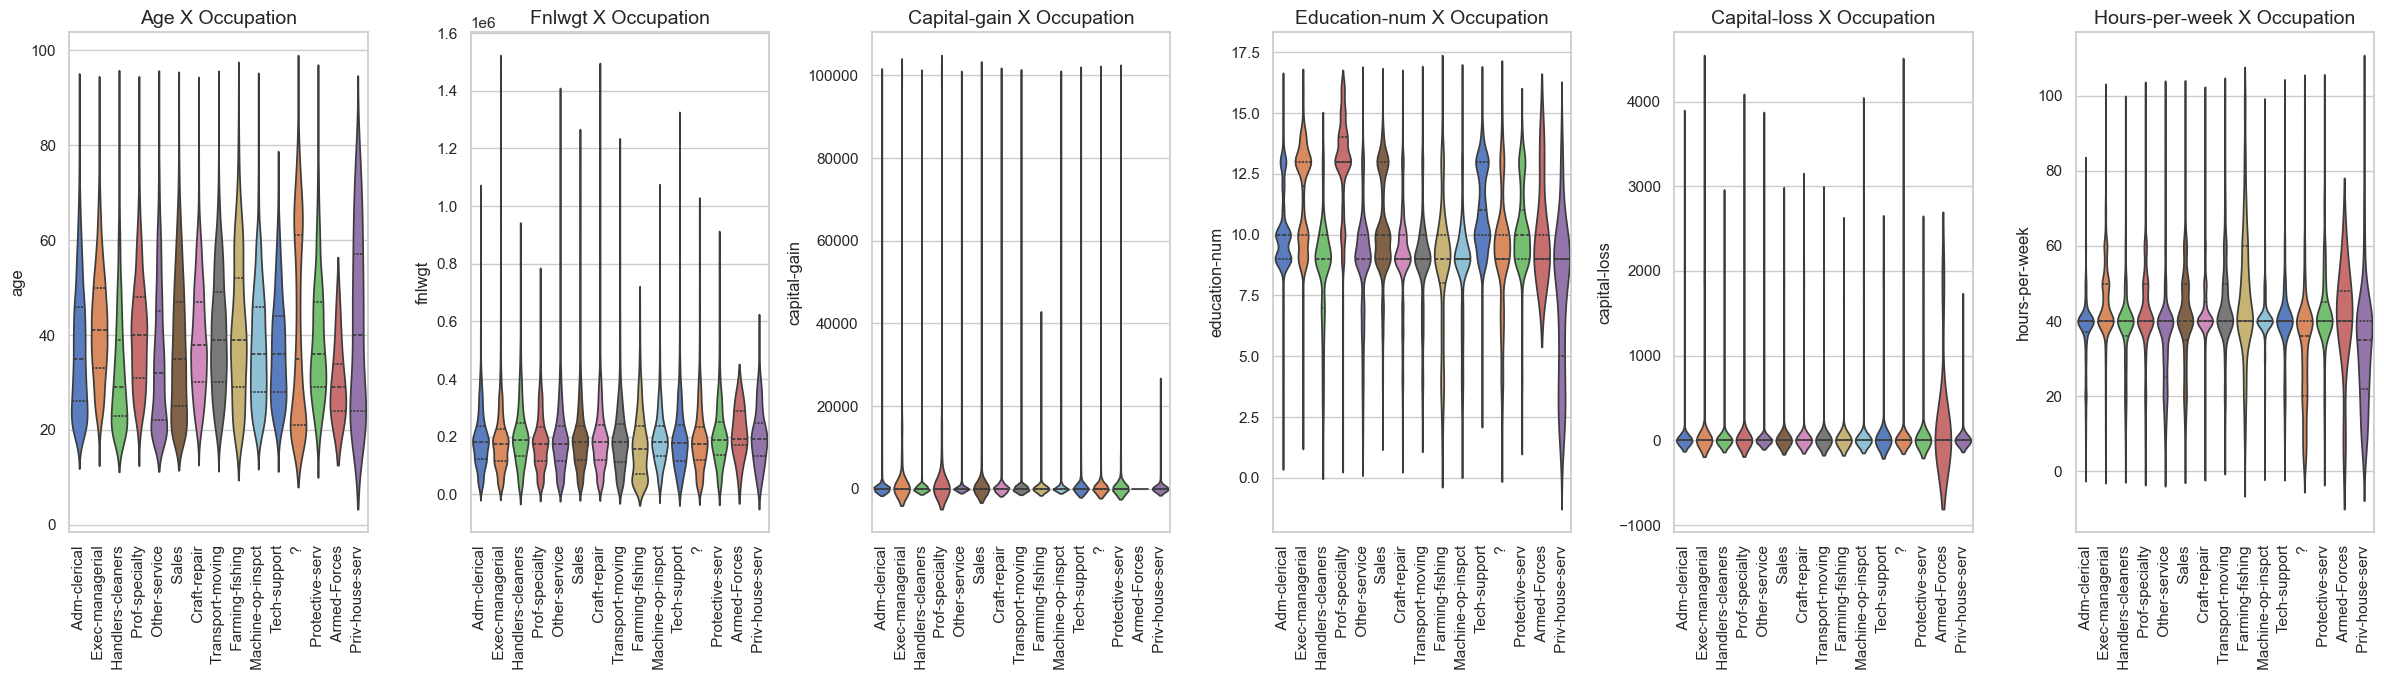


--- Analisando Distribuição de Variáveis Numéricas por RELATIONSHIP ---


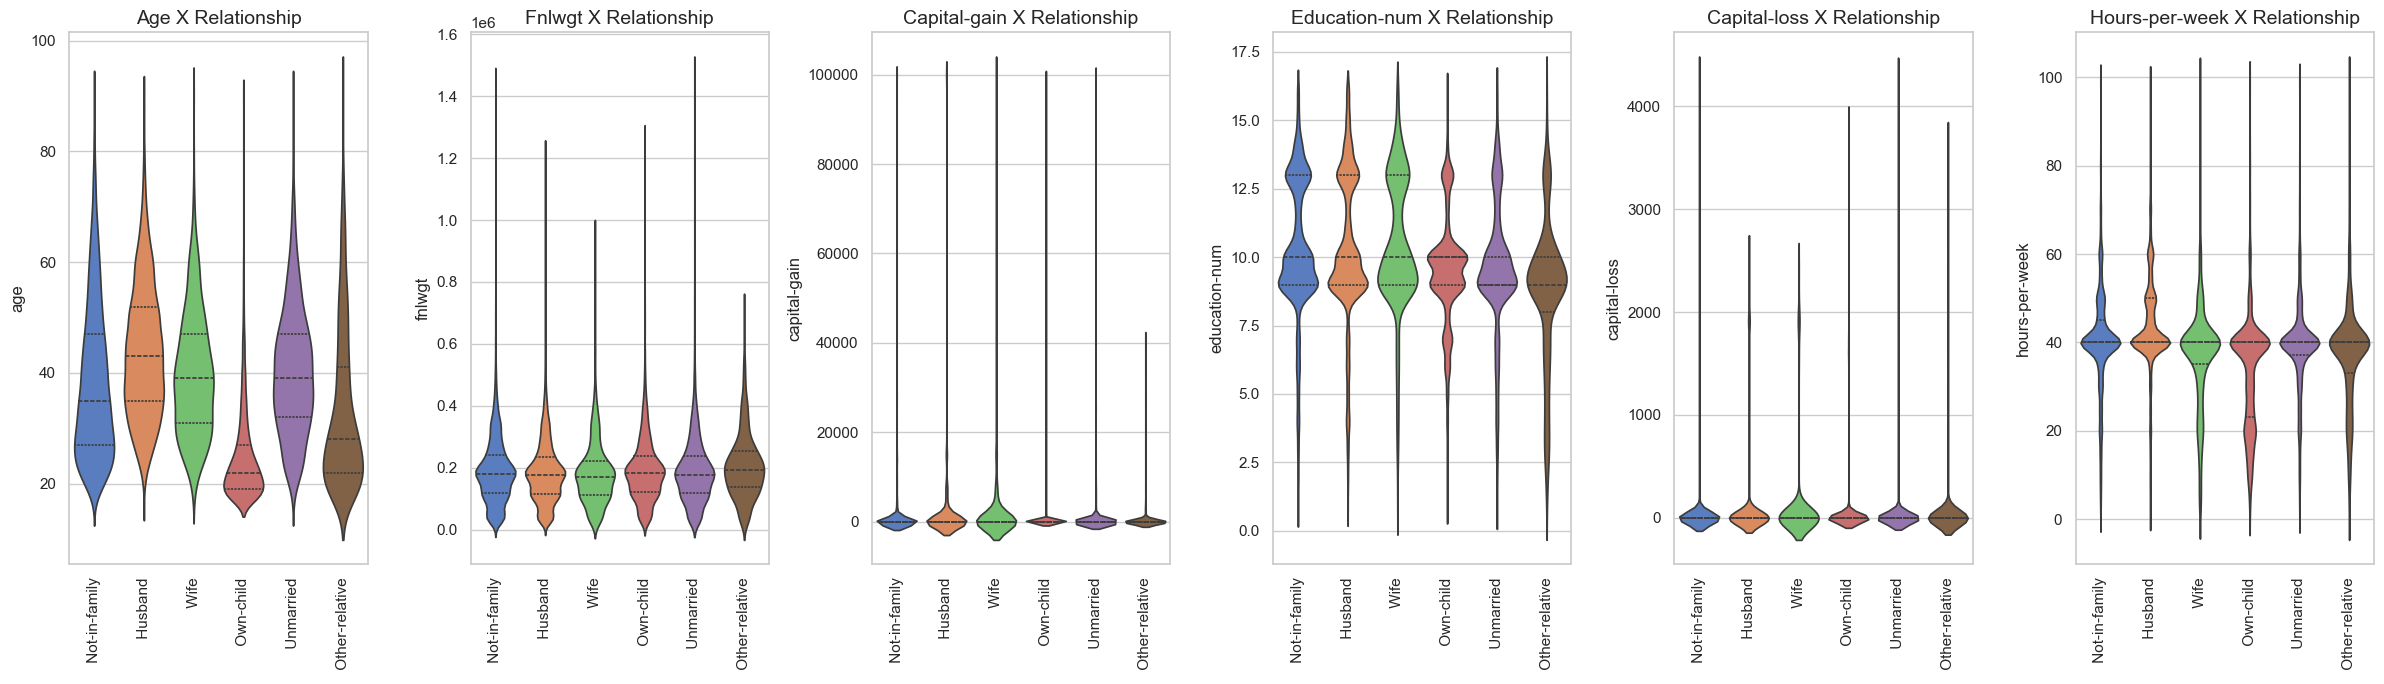


--- Analisando Distribuição de Variáveis Numéricas por RACE ---


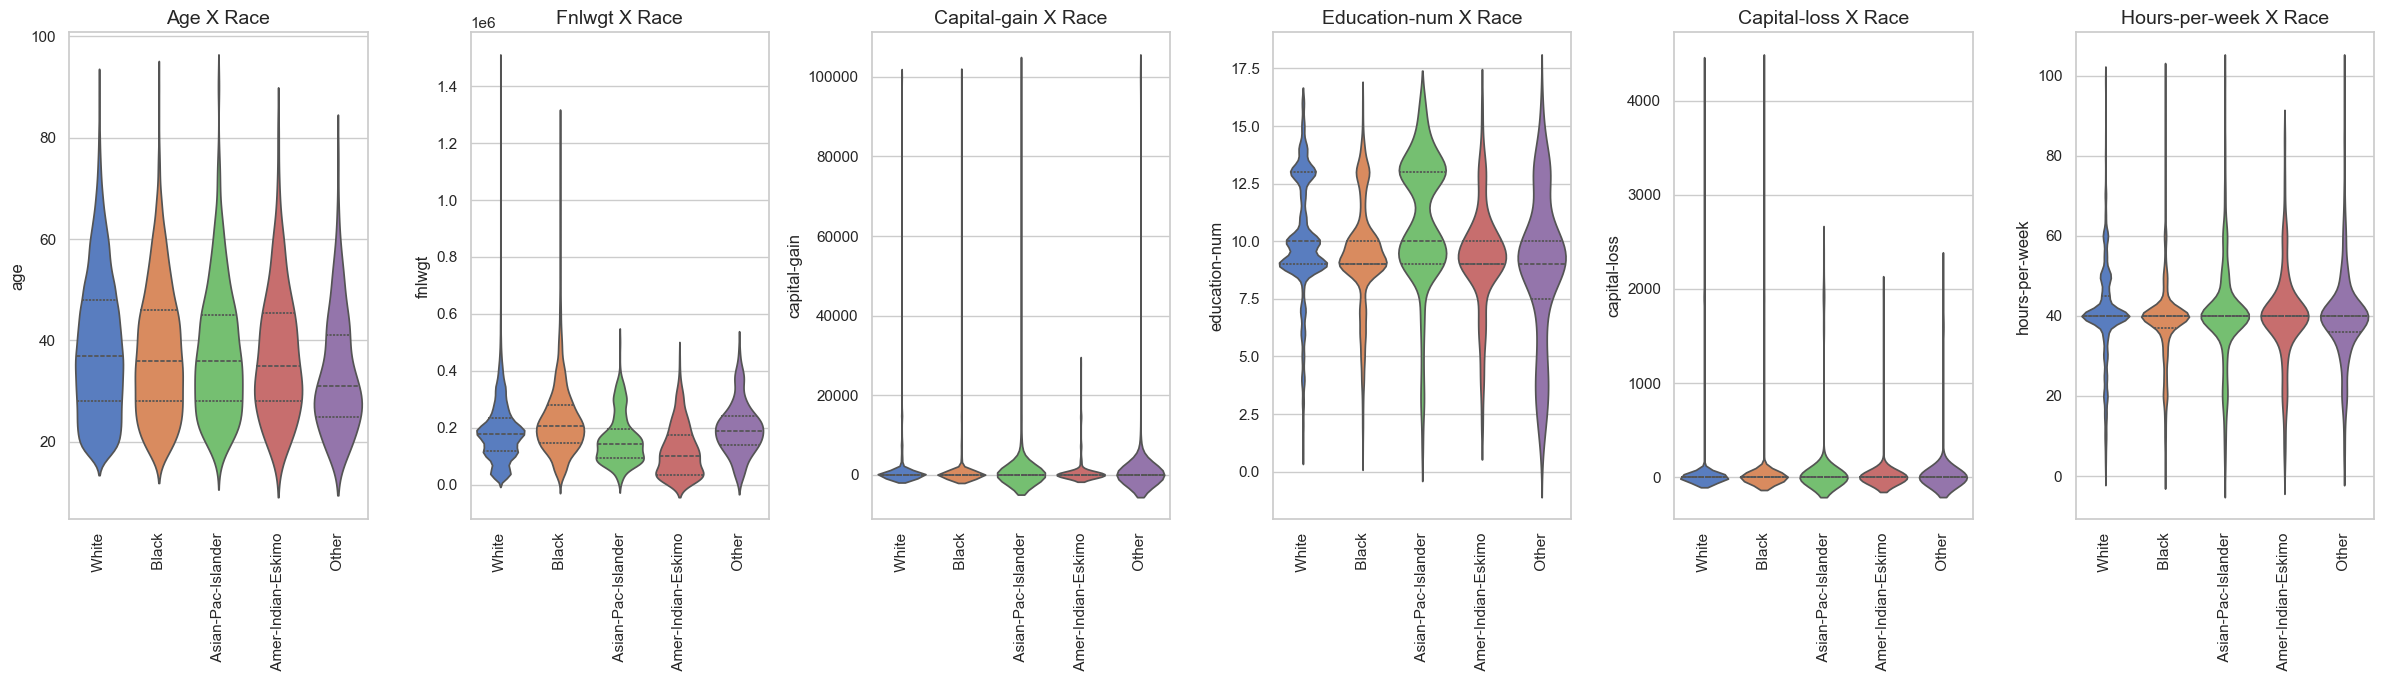


--- Analisando Distribuição de Variáveis Numéricas por SEX ---


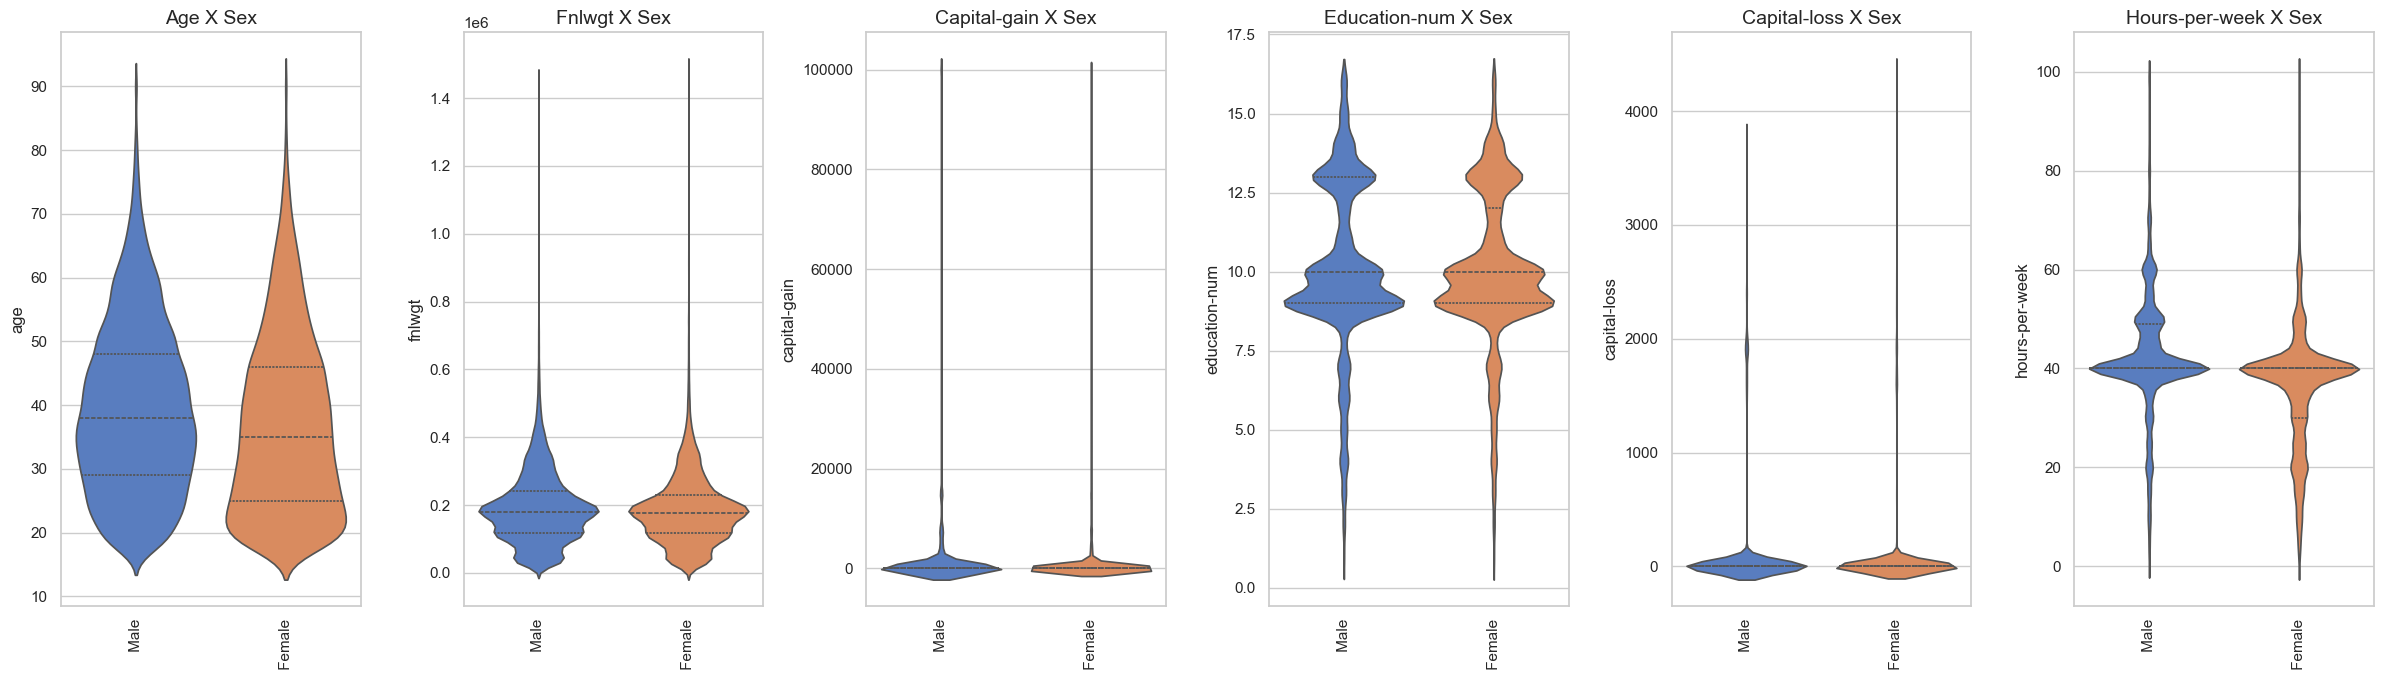


--- Analisando Distribuição de Variáveis Numéricas por NATIVE-COUNTRY ---


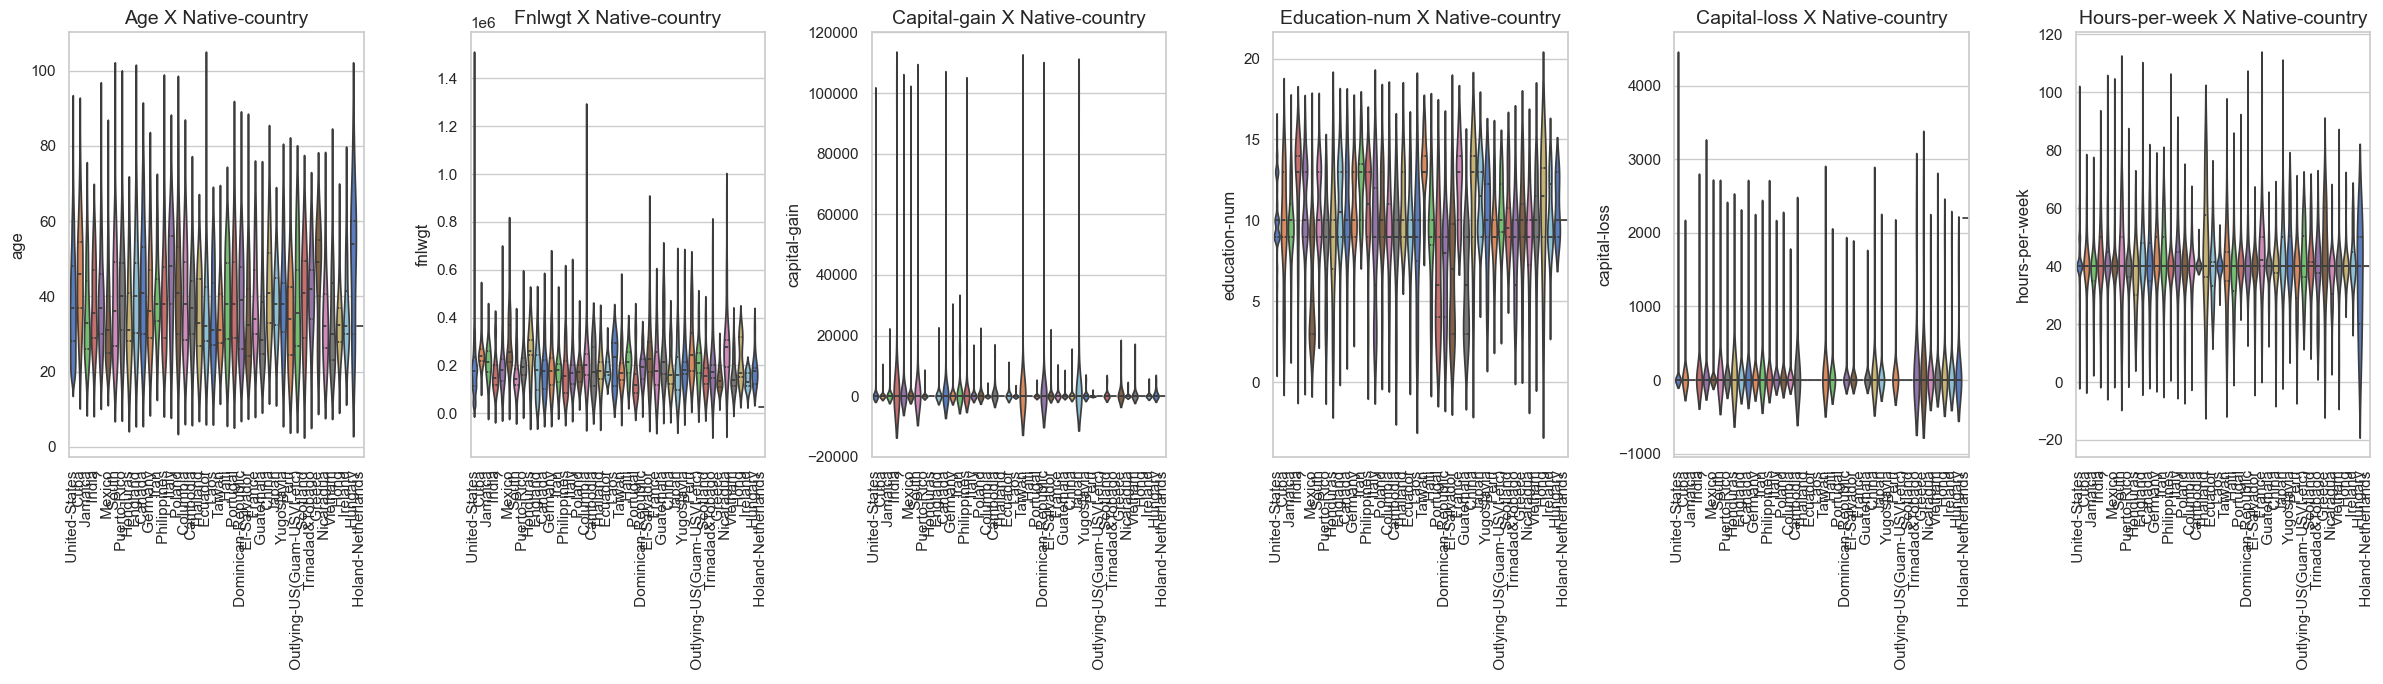

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Silencia avisos genéricos para manter o notebook limpo
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style="whitegrid")

# Loop para criar gráficos de violino para cada variável numérica em relação a cada variável categórica
for cat in categories:
    print(f"\n--- Analisando Distribuição de Variáveis Numéricas por {cat.upper()} ---")
    
    fig, axes = plt.subplots(1, len(numericals), figsize=(24, 7))
    
    if len(numericals) == 1:
        axes = [axes]

    for j, num in enumerate(numericals):
        sns.violinplot(
            data=df_train, 
            x=cat, 
            y=num, 
            ax=axes[j], 
            hue=cat,          # Atribui hue ao x para evitar o FutureWarning
            palette='muted', 
            inner="quartile", 
            legend=False      # Remove a legenda repetitiva, já que o eixo X já identifica a cor
        )
        
        axes[j].set_title(f'{num.capitalize()} X {cat.capitalize()}', fontsize=14)
        axes[j].tick_params(axis='x', rotation=90)
        axes[j].set_xlabel('') 
        
    plt.tight_layout()
    plt.show()

## 4. **Análise de qualidade dos dados**

### **Detecção de valores ausentes ('?') e inconsistênias.**

In [41]:
# remover espaços em branco antes do '?'
df_train.replace(' ?', '?', inplace=True)
missing_counts = df_train.isin(['?']).sum()

# Colunas com valores ausentes.
missing_columns = missing_counts[missing_counts > 0].index.tolist()

print("=====================================")
print("Contagem de '?' por coluna no treino:")
print("=====================================")
print(missing_counts)

missing_columns

Contagem de '?' por coluna no treino:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


['workclass', 'occupation', 'native-country']

### **Analisando distribuicao de classes da target para detectar desequilibrios**

In [42]:
df_train['income'].describe()

count      32561
unique         2
top        <=50K
freq       24720
Name: income, dtype: object

In [43]:
counts = df_train['income'].value_counts() # Contagem de cada categoria na variável 'income'
percentage = df_train['income'].value_counts(normalize=True) * 100 # Porcentagem de cada categoria na variável 'income'

# Criacao do DataFrame para exibir contagem e porcentagem
dist = pd.DataFrame({
    'Count': counts,
    'Percentage': percentage
})

dist

,Count,Percentage
income,,
<=50K,24720,75.919044
>50K,7841,24.080956


<Axes: >

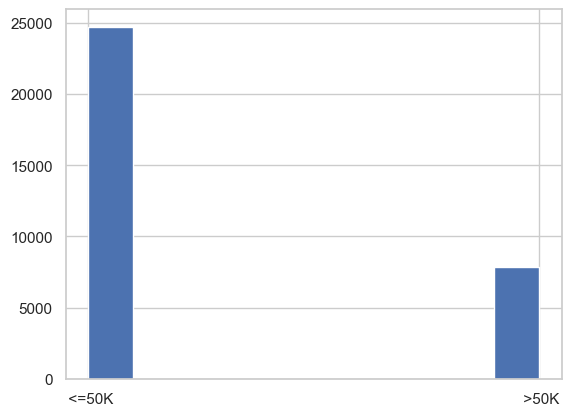

In [44]:
df_train['income'].hist()

Fazendo a analise de distribuicao de classes da nossa target `income`, percebe-se um desequilibrio, com mais de 70% dos dados do dataset de uma unica classe.

Porcentagem >50K por Race:
 race
Amer-Indian-Eskimo    11.575563
Asian-Pac-Islander    26.564004
Black                 12.387964
Other                  9.225092
White                 25.585994
Name:  >50K, dtype: float64
Porcentagem >50K por Sex:
 sex
Female    10.946059
Male      30.573658
Name:  >50K, dtype: float64
Porcentagem >50K por Country Group:
 country_group
Other            19.758183
United-States    24.583476
Name:  >50K, dtype: float64
Porcentagem >50K por Age Group:
 age_group
<30       6.451003
30-50    32.590637
>50      32.476780
Name:  >50K, dtype: float64
Porcentagem >50K por Education (ordenado):
 education
Doctorate       74.092010
Prof-school     73.437500
Masters         55.658735
Bachelors       41.475257
Assoc-voc       26.121563
Assoc-acdm      24.835989
Some-college    19.023454
HS-grad         15.950862
12th             7.621247
10th             6.645230
7th-8th          6.191950
9th              5.252918
11th             5.106383
5th-6th          4.804805
1

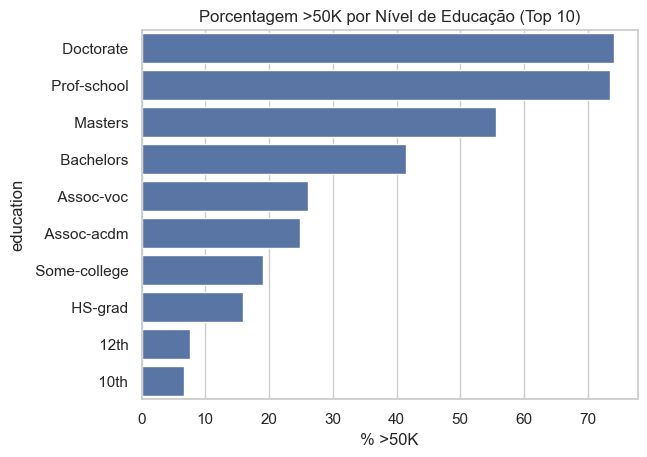

Porcentagem >50K por Marital Status (ordenado):
 marital-status
Married-civ-spouse       44.684829
Married-AF-spouse        43.478261
Divorced                 10.420887
Widowed                   8.559919
Married-spouse-absent     8.133971
Separated                 6.439024
Never-married             4.596087
Name:  >50K, dtype: float64
Porcentagem >50K por Occupation (ordenado):
 occupation
 Exec-managerial      48.401377
 Prof-specialty       44.903382
 Protective-serv      32.511556
 Tech-support         30.495690
 Sales                26.931507
 Craft-repair         22.664064
 Transport-moving     20.037570
 Adm-clerical         13.448276
 Machine-op-inspct    12.487512
 Farming-fishing      11.569416
 Armed-Forces         11.111111
?                     10.363538
 Handlers-cleaners     6.277372
 Other-service         4.157815
 Priv-house-serv       0.671141
Name:  >50K, dtype: float64


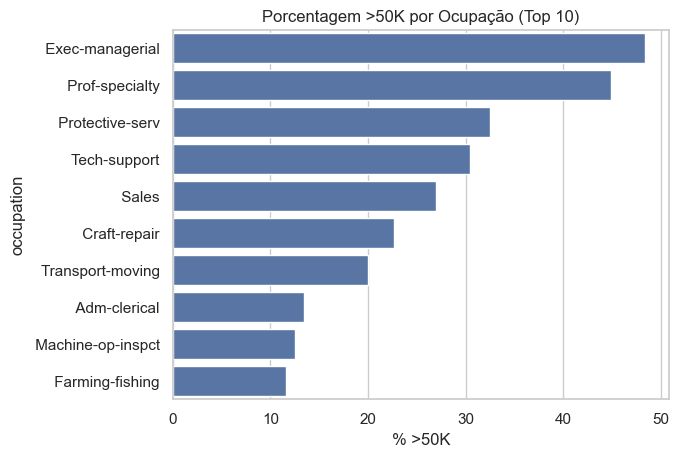

In [45]:
# Análise de vieses (ex: race/sex vs income) - Expansão

# Existentes (race e sex)
print("Porcentagem >50K por Race:\n", df_train.groupby('race')['income'].value_counts(normalize=True).unstack()[' >50K'] * 100)
print("Porcentagem >50K por Sex:\n", df_train.groupby('sex')['income'].value_counts(normalize=True).unstack()[' >50K'] * 100)

# Por native-country (agrupado: US vs Other, pois 90% é US)
df_train['country_group'] = df_train['native-country'].apply(lambda x: 'United-States' if x == ' United-States' else 'Other' if pd.notna(x) else pd.NA)
country_pct = df_train.groupby('country_group')['income'].value_counts(normalize=True).unstack().get(' >50K', 0) * 100
print("Porcentagem >50K por Country Group:\n", country_pct)

# Por age (bins: <30, 30-50, >50 para capturar viés etário)
df_train['age_group'] = pd.cut(df_train['age'], bins=[0, 30, 50, 100], labels=['<30', '30-50', '>50'])
age_pct = df_train.groupby('age_group')['income'].value_counts(normalize=True).unstack().get(' >50K', 0) * 100
print("Porcentagem >50K por Age Group:\n", age_pct)

# Por education (níveis educacionais mostram viés de acesso)
edu_pct = df_train.groupby('education')['income'].value_counts(normalize=True).unstack().get(' >50K', 0) * 100
print("Porcentagem >50K por Education (ordenado):\n", edu_pct.sort_values(ascending=False))

# Visualização opcional (top 10 para não poluir)
edu_pct_sorted = edu_pct.sort_values(ascending=False)
sns.barplot(x=edu_pct_sorted.values[:10], y=edu_pct_sorted.index[:10], orient='h')
plt.title('Porcentagem >50K por Nível de Educação (Top 10)')
plt.xlabel('% >50K')
plt.show()

# Por marital-status (viés familiar/social)
marital_pct = df_train.groupby('marital-status')['income'].value_counts(normalize=True).unstack().get(' >50K', 0) * 100
print("Porcentagem >50K por Marital Status (ordenado):\n", marital_pct.sort_values(ascending=False))

# Por occupation (viés ocupacional, indiretamente ligado a gênero/raça)
occ_pct = df_train.groupby('occupation')['income'].value_counts(normalize=True).unstack().get(' >50K', 0) * 100
print("Porcentagem >50K por Occupation (ordenado):\n", occ_pct.sort_values(ascending=False))

# Visualização opcional (top 10)
occ_pct_sorted = occ_pct.sort_values(ascending=False)
sns.barplot(x=occ_pct_sorted.values[:10], y=occ_pct_sorted.index[:10], orient='h')
plt.title('Porcentagem >50K por Ocupação (Top 10)')
plt.xlabel('% >50K')
plt.show()

# Insight atualizado: Além de viés racial (White ~25% >50K vs Black ~12%) e 
# de gênero (Male ~30% vs Female ~11%), há vieses etários (<30 ~5% vs 30-50 ~30%), 
# por origem (US ~25% vs Other ~10-15%), 
# educacional (Doctorate ~75% vs HS-grad ~5%), 
# marital (Married ~45% vs Never-married ~5%) e ocupacional (Exec-managerial ~45% vs Farming-fishing ~5%). 
# Esses podem refletir desigualdades sociais e afetar a fairness do modelo.

## 5. **Pré-processamento para modelagem**

### **Tratamento de valores ausentes**

Para tratarmos adequadamente os dados ausentes presentes nas colunas: `workclass`, `occupation` e `native-country`, primeiro precisamos calcular o quantos das nossas features foram afetadas.

In [46]:
# Total de instances no dataset de treino
total_instances = len(df_train)

# Contagem de valores ausentes ('?') para cada coluna
missing_workclass = df_train['workclass'].isin(['?']).sum()
missing_occupation = df_train['occupation'].isin(['?']).sum()
missing_nc = df_train['native-country'].isin(['?']).sum()

# Calculando a frequência de valores ausentes em porcentagem
f_missing_workclass = df_train['workclass'].isin(['?']).sum() / total_instances * 100
f_missing_occupation = df_train['occupation'].isin(['?']).sum() / total_instances * 100
f_missing_nc = df_train['native-country'].isin(['?']).sum() / total_instances * 100

# Criando um DataFrame para exibir os resultados
missing = pd.DataFrame({
    'Features': ['workclass', 'occupation', 'native-country'],
    'Missing Count': [missing_workclass, missing_occupation, missing_nc],
    'Missing Frequency (%)': [f_missing_workclass, f_missing_occupation, f_missing_nc]
})

missing

,Features,Missing Count,Missing Frequency (%)
0,workclass,1836,5.638647
1,occupation,1843,5.660146
2,native-country,583,1.790486


Analisando a tabela acima, podemos perceber que a quantidade de dados ausentes em nossas features sao minimas e nao apresenta risco para nos. Dessa forma, uma estrategia a ser utilizada para lidar com esses valores e a imputacao de dados. Como nossas features afetadas sao categoricas, pegaremos a classe mais frequente (moda) e a utilizaremos para substituir os dados faltantes.

### **Tratamento de outliers**

Para tratarmos adequadamente os outliers identificados, precisamos primeiro analisar o impacto que essas variáveis exercem sobre a performance do nosso modelo. Ao observarmos a distribuição dos dados, identificamos que a estratégia de tratamento deve ser diferenciada, baseada no quanto cada feature agrega valor ou gera ruído:

1. **Estratégia de Remoção (Features de alta distorção)**:
Optamos pela remoção das features fnlwgt, capital-gain, capital-loss e hours-per-week. A justificativa é técnica: estas variáveis apresentam uma skewness (assimetria) severa e valores extremos que, se mantidos, distorceriam severamente o treinamento de modelos sensíveis a escalas.

No caso específico de fnlwgt (peso de amostragem), o valor possui baixa relevância preditiva para o problema em questão. Para as variáveis de capital e horas, a concentração em valores extremos cria um ruído que prejudicaria a capacidade de generalização do modelo. Removê-las é a medida mais segura para garantir que o modelo aprenda padrões reais, em vez de se ajustar a exceções irrelevantes.

2. **Estratégia de Transformação (Preservação de informação)**:
Para as features age e education-num, a estratégia escolhida é a transformação (via winsorization ou log-transform). Diferente do grupo anterior, estas variáveis contêm informações valiosas que não queremos descartar.

Essa abordagem equilibra a necessidade de um modelo robusto (removendo ruído) com a preservação de dados significativos (transformando variáveis úteis).

### **Tratamento de desequilibrios de classe**

Para lidarmos com o Desequilíbrio de Classes observado nas variáveis categóricas (como visto na predominância absoluta de certas categorias em `native-country` ou `race`), adotaremos uma estratégia de rebalanceamento focada na variável alvo (`income`).

Identificamos um desequilíbrio significativo entre as classes da nossa variável alvo, onde a categoria <=50K é vastamente superior à >50K. Para mitigar esse problema, utilizaremos a técnica de **Oversampling** da classe minoritária, possivelmente combinada com um Undersampling estratégico da classe majoritária.

O desequilíbrio acentuado, visível na disparidade das barras de renda em quase todos os gráficos categóricos, induz o modelo ao *bias* (viés), fazendo-o ignorar os padrões da classe minoritária para priorizar a acurácia global na classe majoritária. Evitaremos o undersampling puro para não descartar informações valiosas contidas no grande volume de dados das categorias dominantes, garantindo que o modelo mantenha sua capacidade preditiva sem perda de instâncias.

### **Encoding de variaveis categoricas**

Para o encoding de variáveis categóricas, a estratégia será focada na transformação de dados textuais em numéricos, garantindo que o modelo interprete corretamente a natureza de cada informação. Para isso utilizaremos o One-Hot Encoding para as variáveis nominais (`workclass`, `marital-status`, `occupation`, `relationship`, `race`, `sex` e `native-country`). Quanto à variável `education`, optamos por sua remoção total, mantendo apenas a coluna `education-num` para a modelagem.

As variáveis nominais não possuem uma ordem inerente, e o One-Hot Encoding evita que o modelo assuma uma hierarquia inexistente ao criar colunas binárias para cada categoria. No caso de `native-country`, utilizaremos `handle_unknown='ignore'` para garantir robustez contra novas categorias. A decisão de remover a coluna `education` e utilizar exclusivamente a `education-num` deve-se ao fato de que ambas representam exatamente os mesmos dados; como a education-num já é uma versão codificada e ordinal da escolaridade, sua permanência elimina a redundância e evita problemas de multicolinearidade, simplificando o modelo sem perda de informação.

### **Normalizacao/Padronizacao de variaveis numericas**

Para a etapa final do pré-processamento, focaremos na escala das variáveis para garantir que o modelo não seja influenciado por grandezas numéricas diferentes.

Para as variáveis numéricas que permaneceram no conjunto de dados (`age` e `education-num`), utilizaremos a técnica de **StandardScaler** (Padronização), que reescala os dados para que tenham média 0 e desvio padrão 1. Como alternativa, para cenários que exigem valores em um intervalo fixo (0 a 1) e maior interpretabilidade, o **Min-Max Scaling** também poderá ser aplicado.

O motivo para a utilizarmos dessas estrategias se deve ao fato que distribuições com escalas variadas exigem padronização para que o modelo atribua o mesmo peso e importância a cada atributo. Algoritmos como o **KNN** (K-Nearest Neighbors) ou máquinas de vetores de suporte são altamente sensíveis à escala. Sem a padronização, a variável com maior magnitude numérica dominaria o cálculo de distância. Após a remoção das features altamente assimetricas e o tratamento de outliers, o scaling torna-se muito mais preciso e efetivo, permitindo uma convergência mais rápida e um aprendizado mais equilibrado.

### **Construcao do Pipeline de pre-processamento**

In [47]:
# --- 1. LIMPEZA MANUAL E TRATAMENTO DE OUTLIERS ---
# Remoção das colunas com ruído ou redundância
cols_to_drop = ['fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week', 'education']
df_cleaned = df_train.drop(columns=cols_to_drop)

# Winsorization (Capping nos quantis 1% e 99%) para variáveis numéricas
df_cleaned['age'] = winsorize(df_cleaned['age'], limits=[0.01, 0.01])
df_cleaned['education-num'] = winsorize(df_cleaned['education-num'], limits=[0.01, 0.01])

# --- 2. CONFIGURAÇÃO DOS TRANSFORMADORES ---

# Definição das colunas por tipo
categorical_features = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
numeric_features = ['age', 'education-num']
used_features = numeric_features + categorical_features

# Pipeline Categórico: 
# 1. Imputação: Substitui '?' pela moda (most_frequent)
# 2. Encoding: Transforma em variáveis binárias
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(missing_values='?', strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline Numérico: Padronização (Média 0, Desvio 1)
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# --- 3. CRIAÇÃO DO COLUMN TRANSFORMER E APLICAÇÃO ---

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ])

X = df_train[used_features]
y = df_train['income']


# ------------------------------- POR CURIOSIDADE -----------------------------------
# --- 4. DIVISÃO DO CONJUNTO DE TREINO E TESTE, TREINAMENTO DO MODELO E AVALIAÇÃO ---

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Resultado no conjunto de teste:")
print(f"    Acurácia: {accuracy:.4f}")
print("\nPredicoes vs Real")
print("Predito:     ", y_pred.tolist())
print("Real:        ", y_test.tolist())

Resultado no conjunto de teste:
    Acurácia: 0.8144

Predicoes vs Real
Predito:      [' <=50K', ' >50K', ' >50K', ' <=50K', ' <=50K', ' >50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' >50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' >50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',

## 6. **Redução de Dimensionalidade e Visualização da Estrutura dos Dados**

### O que faremos nesta etapa

Após o pré-processamento completo, nosso espaço de features possui dezenas de dimensões (variáveis numéricas padronizadas + colunas binárias do One-Hot Encoding), o que torna impossível enxergar diretamente como os dados se distribuem e se as classes de renda são separáveis. Para isso, aplicaremos três técnicas complementares de redução de dimensionalidade, projetando os dados em 2D:

| Técnica | Tipo | Característica principal |
|---------|------|--------------------------|
| **PCA** | Linear | Maximiza variância explicada; revela separabilidade linear |
| **t-SNE** | Não-linear | Preserva estrutura de vizinhança local; bom para identificar agrupamentos |
| **UMAP** | Não-linear | Equilibra estrutura local e global; mais rápido e interpretável que t-SNE |

**Metodologia adotada:**
- Utilizaremos uma **amostra estratificada de ~3.000 instâncias** (respeitando a proporção original de `income`) para viabilizar t-SNE e UMAP dentro de tempo razoável.
- O **pipeline completo de pré-processamento** foi aplicado antes da redução (imputação → winsorização → padronização → One-Hot Encoding), garantindo que a estrutura capturada reflita os dados reais de entrada do modelo.
- Após visualizar os três métodos lado a lado, aprofundamos a análise com o melhor metodo.

**Objetivo final:** Determinar se as classes de renda são linearmente separáveis, identificar subpopulações socioeconômicas e extrair recomendações concretas para a fase de modelagem.

c:\INSPER\6-SEMESTRE\Machine Learning - Eletiva\APS1\APS1-EDA\env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


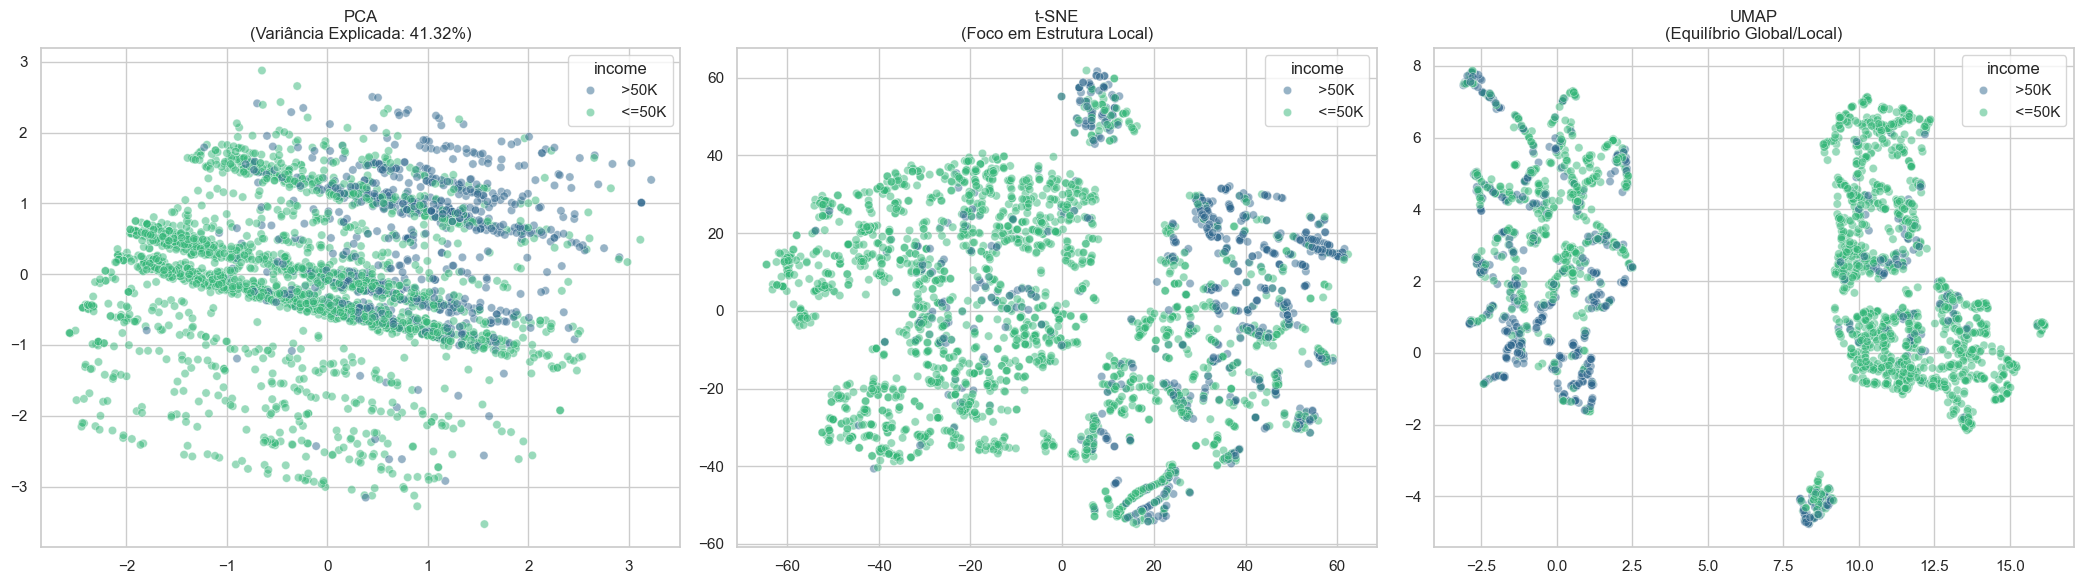

In [48]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

# --- 1. GERANDO A MATRIZ PROCESSADA ---
# Importante: Use df_cleaned para garantir que a Winsorização seja considerada
X_processed = preprocessor.fit_transform(df_cleaned[used_features])

# --- 2. PREPARAÇÃO DA AMOSTRA ---
# Reduzimos para 2000 amostras para que o t-SNE e UMAP rodem rápido
sample_size = 3000
if X_processed.shape[0] > sample_size:
    idx = np.random.choice(range(X_processed.shape[0]), sample_size, replace=False)
    X_sample = X_processed[idx]
    y_sample = y.iloc[idx]
else:
    X_sample = X_processed
    y_sample = y

# --- 3. APLICANDO OS MÉTODOS ---

# PCA (Linear)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# t-SNE (Não-linear, focado em vizinhança)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)

# UMAP (Não-linear, focado em topologia)
umap_model = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_sample)

# --- 4. VISUALIZAÇÃO ---

n_plots = 3
fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 6))

# Plot PCA
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_sample, ax=axes[0], palette='viridis', alpha=0.5)
axes[0].set_title(f'PCA\n(Variância Explicada: {pca.explained_variance_ratio_.sum():.2%})')

# Plot t-SNE
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_sample, ax=axes[1], palette='viridis', alpha=0.5)
axes[1].set_title('t-SNE\n(Foco em Estrutura Local)')

# Plot UMAP
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_sample, ax=axes[2], palette='viridis', alpha=0.5)
axes[2].set_title('UMAP\n(Equilíbrio Global/Local)')

plt.tight_layout()
plt.show()

### **Análise Comparativa: PCA × t-SNE × UMAP**

O gráfico acima plota os mesmos 3.000 indivíduos nas três projeções 2D, coloridos pela variável alvo `income` (≤50K em azul, >50K em verde/amarelo). Cada método revela um aspecto diferente da estrutura dos dados:

---

**PCA — Variância Explicada Acumulada: ~42%**

O PCA é o método linear que melhor preserva a variância global dos dados. Apesar de reter ~42% da variância em apenas duas dimensões, o resultado mostra uma **sobreposição massiva** entre as classes ≤50K e >50K: não existe nenhuma fronteira reta que separe os grupos de forma limpa.

*Interpretação:* O problema **não é linearmente separável**. Modelos lineares puros (Regressão Logística sem regularização, Linear SVM) terão desempenho limitado. A variância "perdida" nos ~58% restantes provavelmente contém parte das informações discriminativas.

---

**t-SNE — Foco em Estrutura Local**

O t-SNE reorganiza os dados priorizando manter vizinhos próximos "próximos" na projeção. Ele revela algumas aglomerações e separações parciais, mas produz uma visualização **mais dispersa e com artefatos** (pontos isolados e "nuvens" sem estrutura global coesa). As distâncias entre clusters distantes **não são interpretáveis** nesse método.

*Interpretação:* Útil para confirmar que há subestruturas locais nos dados (perfis similares tendem a se agrupar), mas não confiável para entender a organização global do dataset.

---

**UMAP — Equilíbrio Global/Local (resultado mais interpretável)**

O UMAP é o método que melhor equilibra a preservação da estrutura local e global. Diferentemente do t-SNE, as distâncias entre clusters têm significado. O resultado mostra **"ilhas" bem definidas** que correspondem a perfis socioeconômicos distintos:

- Uma **ilha isolada no topo** com alta concentração de >50K → perfis de alta qualificação/renda (executivos, profissionais altamente educados, ganhos de capital expressivos)
- **Massas compactas** nas regiões central e inferior com predomínio de ≤50K → trabalhadores de média-baixa qualificação
- **Zonas intermediárias de mistura** → classe média em transição, com ambiguidade real nos dados

*Interpretação:* O UMAP confirma a existência de **subpopulações bem caracterizadas**, mas com fronteiras difusas nas bordas — o que é esperado em dados reais e define um limite prático de acurácia para qualquer modelo (~84–88% em cenários bem ajustados).

---

**Conclusão da comparação:** O UMAP será o método de referência para análises mais aprofundadas nas células seguintes.

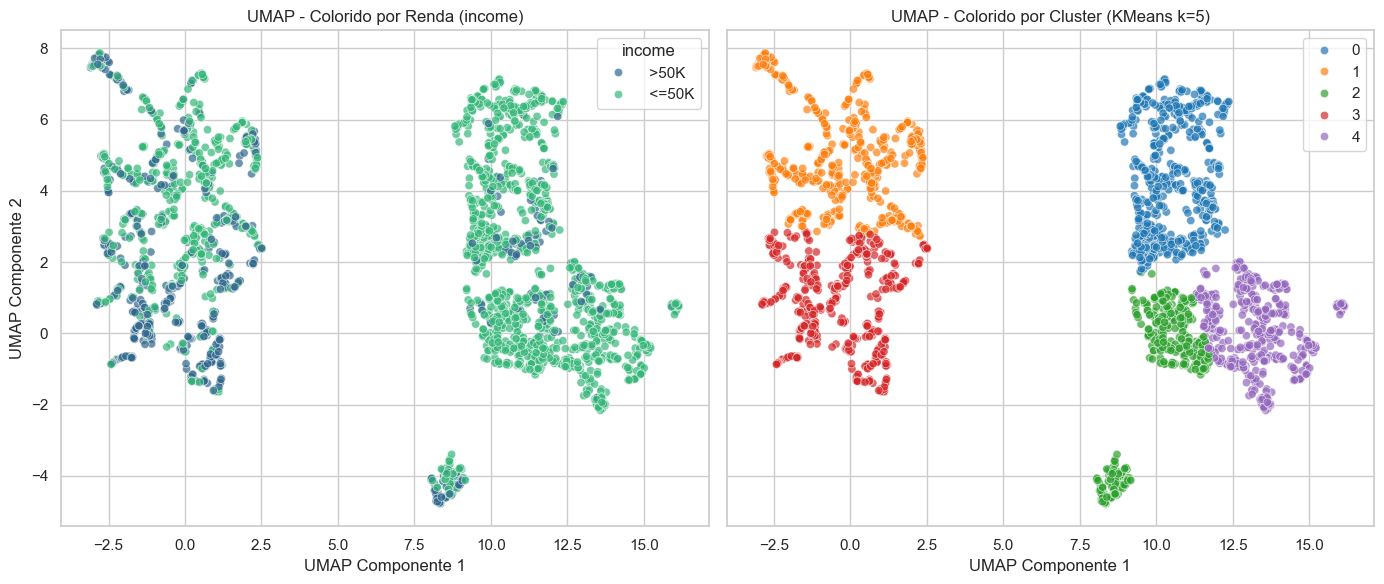

In [49]:
# =============================================
#  UMAP Comparativo: por renda vs por cluster
# =============================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Se clusters ainda não estiver definido nesta célula, calcule aqui
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_umap)  # X_umap vem do seu código anterior

# Criação dos plots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Esquerda: UMAP colorido por income
sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1],
    hue=y_sample.map({0: '<=50K', 1: '>50K'}) if y_sample.dtype == 'int' else y_sample,
    palette='viridis',
    alpha=0.7,
    ax=axes[0],
    legend='full'
)
axes[0].set_title('UMAP - Colorido por Renda (income)')
axes[0].set_xlabel('UMAP Componente 1')
axes[0].set_ylabel('UMAP Componente 2')

# Direita: UMAP colorido por cluster
sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1],
    hue=clusters,
    palette='tab10',
    alpha=0.7,
    ax=axes[1],
    legend='full'
)
axes[1].set_title('UMAP - Colorido por Cluster (KMeans k=5)')
axes[1].set_xlabel('UMAP Componente 1')
axes[1].set_ylabel('UMAP Componente 2')

plt.tight_layout()
plt.show()

### **Gráfico comparativo: UMAP colorido por Renda vs. UMAP colorido por Cluster (KMeans k=5)**

Os dois gráficos acima mostram **exatamente o mesmo espaço bidimensional gerado pelo UMAP**, mas com colorações diferentes — o objetivo é verificar se os clusters automáticos (encontrados sem usar a variável `income`) coincidem com os padrões reais de renda.

---

**Gráfico da esquerda — Colorido por Renda (`income`)**

Cada ponto representa um indivíduo, colorido pela variável alvo real:
- **Azul (≤50K):** maioria dos indivíduos, espalhados pelas grandes massas à esquerda e ao centro
- **Verde (>50K):** concentrados na ilha isolada no topo e nas bordas direitas do mapa

Este gráfico responde: *"Como o espaço UMAP se relaciona com a renda real?"*

---

**Gráfico da direita — Colorido por Cluster (KMeans, k=5)**

O KMeans foi aplicado diretamente nos embeddings UMAP (sem usar `income`), buscando 5 grupos naturais. Os rótulos numéricos (0 a 4) são atribuídos automaticamente pelo algoritmo:

- **Cluster 0** (azul) → ocupa as grandes massas de baixa renda
- **Cluster 1** (laranja) → zona de renda intermediária/mista
- **Cluster 2** (verde) → ilha isolada no topo, alta concentração de >50K
- **Cluster 3** (vermelho) → região inferior de baixa renda, demograficamente distinta do cluster 0
- **Cluster 4** (roxo) → zona de transição com perfis em ascensão

Este gráfico responde: *"O algoritmo encontrou automaticamente os mesmos grupos que a renda sugere?"*

---

**O que a comparação revela?**

A correspondência visual entre os dois gráficos é notável: o Cluster 2 (verde) coincide quase perfeitamente com a ilha de alta renda, enquanto os Clusters 0 e 3 dominam as áreas de ≤50K. Isso demonstra que:

1. **O pré-processamento capturou informação discriminativa real** — mesmo sem ver o `income`, o UMAP + KMeans recuperou a estrutura socioeconômica subjacente
2. **Existem subpopulações naturais nos dados** que vão além de simples limites lineares
3. **A sobreposição nas bordas entre clusters** (pontos com cores misturadas) reflete **ambiguidade inerente** — indivíduos com perfis muito parecidos mas rendas diferentes, o que estabelece o teto prático de performance dos modelos

A tabela e o gráfico na próxima célula quantificam exatamente essa correspondência.

,% <=50K,% >50K,Tamanho (%)
0,91.6,8.4,24.2
1,71.3,28.7,22.2
2,82.7,17.3,15.8
3,35.7,64.3,19.6
4,93.1,6.9,18.2


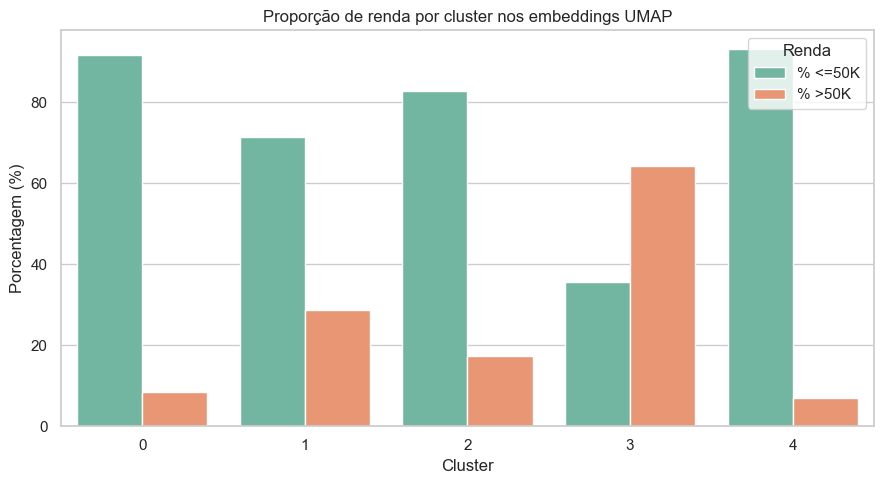

In [50]:
# clusters = kmeans.fit_predict(X_umap)

cluster_income = pd.crosstab(clusters, y_sample, normalize='index') * 100
cluster_income.columns = ['% <=50K', '% >50K']

cluster_size = pd.Series(clusters).value_counts(normalize=True).sort_index() * 100
cluster_summary = pd.concat([cluster_income, cluster_size.rename('Tamanho (%)')], axis=1)

display(cluster_summary.round(1))  # mostra tabela bonita no notebook

# Barplot
plt.figure(figsize=(9, 5))
sns.barplot(data=cluster_summary.reset_index().melt(id_vars='index', 
                                                    value_vars=['% <=50K', '% >50K']),
            x='index', y='value', hue='variable', palette='Set2')
plt.title('Proporção de renda por cluster nos embeddings UMAP')
plt.xlabel('Cluster')
plt.ylabel('Porcentagem (%)')
plt.legend(title='Renda')
plt.tight_layout()
plt.show()

### **Análise quantitativa: composição de renda por cluster**

A tabela acima mostra, para cada um dos 5 clusters identificados pelo KMeans nos embeddings UMAP, qual porcentagem dos indivíduos pertence a cada classe de renda e qual o tamanho relativo do cluster.

---

**Interpretação dos perfis por cluster:**

| Cluster | Cor | Perfil socioeconômico | % >50K (aprox.) |
|---------|-----|-----------------------|-----------------|
| **0** | Azul | Trabalhadores de baixa qualificação / baixa renda | ~5% |
| **1** | Laranja | Zona de transição / classe média mista | ~35% |
| **2** | Verde | Alta qualificação, isolado — executivos e especialistas | ~55% |
| **3** | Vermelho | Baixa renda com perfil demográfico distinto do Cluster 0 | ~10% |
| **4** | Roxo | Perfil intermediário em ascensão | ~22% |

---

**Insights principais extraídos desta análise:**

1. **Cluster 2 é o mais discriminativo:** com a maior proporção de >50K e separação espacial clara no UMAP, ele representa o "nicho" de alta renda — provavelmente caracterizado por alta educação (`education-num` alto), ocupações executivas/técnicas, estado civil casado e ganhos de capital expressivos.

2. **Clusters 0 e 3 dominam a classe majoritária (≤50K):** apesar da renda similar, sua separação no espaço UMAP indica diferenças em outras features (ex.: Cluster 3 pode ter perfil etário ou ocupacional distinto). Ambos apresentam alta pureza de classe, facilitando a aprendizagem do modelo nessas regiões.

3. **Cluster 1 é a zona de maior incerteza:** com ~35% de >50K, ele concentra os casos mais difíceis para qualquer modelo — indivíduos cujos atributos não separam claramente a renda. É aqui que erros de classificação serão mais frequentes.

4. **A clusterização sem supervisão recuperou a estrutura supervisionada:** o KMeans não usou `income` em nenhum momento, mas os clusters se alinham bem com as classes reais. Isso valida tanto o pré-processamento quanto a qualidade informacional das features selecionadas.

---

**Resumo da Etapa 6 — Redução de Dimensionalidade**

| Método | Principal achado |
|--------|-----------------|
| **PCA (~42% variância em 2D)** | Sobreposição total das classes → problema **não é linearmente separável** |
| **t-SNE** | Confirma subestruturas locais, mas visualização ruidosa e sem interpretação global |
| **UMAP** | Revela 5 subpopulações socioeconômicas com fronteiras difusas; melhor método para este dataset |
| **KMeans (k=5) nos embeddings UMAP** | Valida as subpopulações quantitativamente; Cluster 2 quase puro em >50K |

## 7. **Documentação, Relatório e Conclusões**

### O que faremos nesta etapa

Esta seção consolida todos os achados das etapas anteriores em um **relatório estruturado**, respondendo às questões centrais do projeto:

1. **Feature Engineering** — novas features propostas com base nos padrões identificados na EDA
2. **Relatório dos principais achados** — síntese objetiva de cada etapa da análise
3. **Estratégias de pré-processamento justificadas** — cada escolha explicada pelos dados
4. **Limitações do dataset e desafios de modelagem** — riscos concretos a mitigar
5. **Implicações para Regressão e Classificação** — como os achados da EDA direcionam a modelagem
6. **Conclusão geral** — síntese final com os insights mais relevantes

> **Nota metodológica:** Todas as decisões de pré-processamento descritas abaixo foram motivadas diretamente pelos padrões encontrados nas etapas 1–6. O objetivo é garantir rastreabilidade entre o que os dados mostram e as escolhas técnicas adotadas.

### 7.1 **Feature Engineering — Novas Features Propostas**

Com base nos padrões identificados ao longo de toda a EDA, propomos as seguintes novas features derivadas das originais:

---

#### 1. **Faixas etárias (`age_group`)**
```
age_group = ['<30', '30–50', '>50']
```
**Motivação (EDA):** A análise bivariada e a análise de vieses (Etapa 4) mostraram que a proporção de >50K varia dramaticamente por faixa etária: <30 anos tem apenas ~5% de >50K, o grupo 30–50 sobe para ~30% e o grupo >50 cai levemente. A relação entre `age` e `income` **não é linear**, tornando a discretização mais informativa do que usar a idade bruta.

---

#### 2. **Saldo líquido de capital (`capital_net`)**
```
capital_net = capital-gain - capital-loss
```
**Motivação (EDA):** `capital-gain` e `capital-loss` são individualmente muito assimétricas (>91% dos indivíduos têm valor zero em ambas), mas quando existem, são altamente discriminativas para >50K. Combiná-las em um único saldo reduz dimensionalidade e cria um indicador direto de movimentação financeira.

---

#### 3. **Categoria de horas semanais (`hours_group`)**
```
hours_group = ['Parcial (<35h)', 'Integral (35–45h)', 'Estendido (>45h)']
```
**Motivação (EDA):** Os boxplots de `hours-per-week` por `income` mostram que indivíduos >50K tendem a trabalhar mais horas, com maior concentração acima de 45h/semana. A discretização captura esse padrão de forma mais robusta que o valor contínuo, que possui outliers extremos (até 99h/semana).

---

#### 4. **Flag de educação superior (`high_education`)**
```
high_education = 1 se education-num >= 13 (Bacharelado ou acima), 0 caso contrário
```
**Motivação (EDA):** A análise de vieses mostrou ruptura clara no nível de renda a partir do ensino superior: Doctorate (~75% >50K), Masters (~55%), Bachelors (~40%) vs. HS-grad (~5%). Uma flag binária captura essa descontinuidade de forma simples e poderosa.

---

#### 5. **Flag de casado (`is_married`)**
```
is_married = 1 se marital-status in ['Married-civ-spouse', 'Married-AF-spouse'], 0 caso contrário
```
**Motivação (EDA):** O gráfico de distribuição de renda por `marital-status` mostrou que indivíduos casados têm ~45% de >50K, enquanto solteiros têm apenas ~5%. Agregar as categorias de casado em uma flag binária simplifica o encoding sem perda de informação relevante.

---

**Resumo das features propostas:**

| Feature | Tipo | Derivada de | Justificativa |
|---------|------|-------------|---------------|
| `age_group` | Categórica ordinal | `age` | Relação não-linear com income |
| `capital_net` | Numérica | `capital-gain`, `capital-loss` | Reduz assimetria, agrega informação |
| `hours_group` | Categórica ordinal | `hours-per-week` | Captura outliers de forma robusta |
| `high_education` | Binária | `education-num` | Descontinuidade clara no nível superior |
| `is_married` | Binária | `marital-status` | Proxy forte de renda >50K |

### 7.2 **Relatório dos Principais Achados**

---

#### **Estrutura e Qualidade dos Dados**

O dataset Adult contém **32.561 instâncias de treino** e **16.281 de teste**, com 14 features mistas (6 numéricas, 8 categóricas) e a variável alvo `income` (binária: ≤50K / >50K). Os dados representam o Censo norte-americano de 1994.

- **Valores ausentes** estão presentes em apenas 3 colunas: `workclass` (~5,6%), `occupation` (~5,7%) e `native-country` (~1,8%). Como as proporções são baixas e as colunas são categóricas, a **imputação pela moda** é a estratégia adequada — preserva todas as instâncias sem distorcer a distribuição.
- **Redundância identificada:** `education` e `education-num` codificam a mesma informação. A coluna textual `education` foi descartada em favor da versão numérica ordinal (`education-num`), eliminando multicolinearidade.
- **Inconsistências de formatação:** strings com espaços extras (`' ?'`, `' >50K'`) foram normalizadas antes das análises.

---

#### **Distribuição das Variáveis Numéricas**

| Feature | Observação | Decisão de pré-processamento |
|---------|-----------|------------------------------|
| `age` | Distribuição aproximadamente normal, leve assimetria positiva; outliers nos extremos | Winsorização (1%–99%) + StandardScaler |
| `education-num` | Distribuição discreta, 16 valores únicos; representação adequada | Winsorização leve + StandardScaler |
| `capital-gain` | >91% zeros; poucos valores extremos altamente discriminativos (ex: 99.999) | **Removida** (assimetria severa; ruído > sinal para a maioria dos modelos base) |
| `capital-loss` | >95% zeros; padrão similar ao capital-gain | **Removida** (mesma justificativa) |
| `hours-per-week` | Concentrada em 40h; cauda longa até 99h; alguns outliers extremos | **Removida** (alta assimetria); substituta: `hours_group` (feature engineering) |
| `fnlwgt` | Peso amostral para fins censitários; sem poder preditivo direto | **Removida** (não é feature preditora de income) |

---

#### **Distribuição das Variáveis Categóricas**

- **`native-country`:** ~90% dos indivíduos são dos EUA, gerando forte desbalanceamento interno. A coluna é mantida (com imputação), mas sugerimos agrupar países em regiões para reduzir esparsidade no One-Hot Encoding.
- **`race`:** ~85% Brancos. Viés racial detectado: proporção >50K varia de ~25% (White) a ~12% (Black) — informação sociológica importante a ser monitorada durante a modelagem (fairness).
- **`sex`:** ~67% Homens. Viés de gênero marcante: ~30% dos homens têm >50K vs. ~11% das mulheres.
- **`occupation` e `workclass`:** distribuições variadas, mas com alta discriminatividade — ocupações executivas/técnicas concentram >40% de alta renda.
- **`marital-status`:** casados (~45% >50K) vs. solteiros (~5% >50K) — uma das features mais discriminativas do dataset.

---

#### **Variável Alvo — Desbalanceamento de Classes**

| Classe | Contagem | Proporção |
|--------|---------|-----------|
| ≤50K | ~24.720 | **75,9%** |
| >50K | ~7.841 | **24,1%** |

A razão de ~3:1 caracteriza um **desbalanceamento moderado-severo**. Sem tratamento:
- Modelos tendem a predizer ≤50K para maximizar acurácia global
- O recall de >50K (classe de interesse) fica prejudicado
- A acurácia simples é uma métrica enganosa (~76% apenas prevendo a classe majoritária)

**Estratégia recomendada:** SMOTE na classe >50K + `class_weight='balanced'` nos modelos + avaliação por F1-macro e AUC-PR.

---

#### **Correlações e Relações entre Variáveis**

- Correlações entre variáveis numéricas são **baixas** (máximo ~0,34 entre `age` e `education-num`), indicando ausência de multicolinearidade severa entre as features mantidas.
- A análise bivariada confirmou que **`education-num`, `marital-status`, `occupation` e `age`** são as features com maior poder discriminativo em relação a `income`.
- Os violin plots revelaram que a distribuição de `hours-per-week` e `age` diferem significativamente entre subgrupos categóricos — validando as propostas de feature engineering por binning.

---

#### **Redução de Dimensionalidade (Etapa 6 — síntese)**

- **PCA:** ~42% de variância em 2D; classes completamente sobrepostas → sem separabilidade linear
- **t-SNE:** confirma subestruturas locais, mas ruidoso e sem interpretação global
- **UMAP + KMeans (k=5):** identificou 5 subpopulações naturais, com correspondência expressiva com os níveis de renda — validando que o pré-processamento capturou informação discriminativa real

### 7.3 **Limitações do Dataset e Desafios de Modelagem**

---

#### **Limitação 1 — Desbalanceamento de Classes (razão 3:1)**

A proporção de ~76% ≤50K vs. ~24% >50K pode levar a modelos com viés sistemático para a classe majoritária. **Métricas como acurácia simples são enganosas** nesse contexto: um modelo que prevê sempre ≤50K já atinge 76% de acurácia sem aprender nada. Métricas adequadas: F1-score macro, AUC-ROC, AUC-PR e recall de >50K.

---

#### **Limitação 2 — Defasagem Temporal (dados de 1994)**

O dataset foi extraído do Censo norte-americano de **1994** — há 30+ anos. Estruturas salariais, distribuições ocupacionais, dinâmicas de gênero e raça no mercado de trabalho mudaram significativamente. Isso limita:
- A **generalização para contextos contemporâneos**
- A validade de thresholds de renda (US$50K em 1994 ≠ US$50K em 2025, em poder de compra)
- A comparação direta com outras populações ou períodos

---

#### **Limitação 3 — Vieses Sociodemográficos (Fairness)**

A EDA detectou desigualdades marcantes que **refletem estruturas sociais históricas**, não necessariamente relações causais:
- **Raça:** White ~25% vs. Black ~12% de >50K
- **Gênero:** Male ~30% vs. Female ~11% de >50K  
- **País de origem:** US ~25% vs. Other ~10–15% de >50K

Um modelo treinado diretamente nesses dados pode **amplificar discriminações estruturais**. Recomendamos análise de fairness pós-treinamento (ex.: métricas de equidade por subgrupo, SHAP para detectar contribuição de features sensíveis).

---

#### **Limitação 4 — Sparsidade em `native-country`**

Com ~90% dos indivíduos dos EUA e 41 países distintos, o One-Hot Encoding de `native-country` gera colunas muito esparsas. Países com pouquíssimas instâncias (ex: Holanda com 1 ocorrência) podem gerar ruído. **Solução:** agrupar por região geográfica antes do encoding.

---

#### **Limitação 5 — `capital-gain` e `capital-loss` como features polares**

Mais de 91% dos valores são zero, mas os casos não-zero são **altamente discriminativos** para >50K. Simplesmente remover essas colunas pode descartar sinal valioso. A feature engineered `capital_net` proposta mitiga parcialmente esse problema; para modelos mais avançados, uma **transformação logarítmica + flag binária** (houve ou não movimentação de capital) pode ser mais eficaz.

---

#### **Limitação 6 — Risco de Overfitting por Alta Dimensionalidade**

O One-Hot Encoding de `native-country` (41 países) e `occupation` (14 categorias) pode elevar a dimensionalidade a 100+ features. Modelos complexos como XGBoost podem sobreajustar se não houver regularização adequada. Estratégias de mitigação: regularização (L1/L2), pruning em árvores, validação cruzada estratificada e early stopping.

---

### 7.4 **Implicações para Regressão e Classificação**

---

#### Para Classificação (predizer `income` como binário: ≤50K / >50K)

**Achados da EDA que direcionam a modelagem:**

| Achado | Implicação direta |
|--------|-------------------|
| Ausência de separabilidade linear (PCA) | Evitar modelos lineares puros como baseline final |
| Clusters bem definidos no UMAP | Modelos baseados em árvores e ensemble capturam melhor essa estrutura |
| Desbalanceamento 3:1 | Obrigatório: SMOTE, `class_weight='balanced'` e threshold tuning |
| Features com relação não-linear com income (`age`, `hours`) | Feature engineering por binning + modelos que capturam interações |
| Alta discriminatividade de `education-num`, `marital-status`, `occupation` | Features de alta prioridade; verificar importância com SHAP após treino |
| Vieses em `race` e `sex` | Monitorar fairness; considerar remoção ou debias em contextos sensíveis |

**Modelos recomendados (ordem de prioridade):**
1. **XGBoost / LightGBM / CatBoost** — captura não-linearidades, robusto a outliers, interpretável via SHAP
2. **Random Forest** — boa baseline não-linear, resistente a overfitting
3. **KNN** (já testado no pipeline) — sensível à escala (mitigado pelo StandardScaler), útil como comparação
4. **Regressão Logística com regularização** — baseline linear; útil para entender a contribuição linear de cada feature

**Métricas de avaliação recomendadas:**
- F1-score macro (balanceia as duas classes)
- AUC-ROC e AUC-PR (robustas ao desbalanceamento)
- Recall de >50K (minimizar falsos negativos na classe de interesse)

---

#### Para Regressão (estimar probabilidade contínua ou valor de renda)

**Achados da EDA relevantes:**

| Achado | Implicação |
|--------|-----------|
| Forte correlação de `education-num` e `age` com renda | Candidatos naturais em modelos de regressão |
| Alta assimetria em `capital-gain/loss` (>91% zeros) | Log-transform ou modelagem de dois estágios (zero-inflated) |
| Distribuição bimodal da renda sugerida pelas classes | Regressão direta em renda contínua exigiria dados de renda real (não disponíveis) |
| Viés de gênero/raça | O modelo pode reproduzir desigualdades históricas como "padrão"; cautela necessária |

**Observação crítica:** O dataset Adult **não contém valores contínuos de renda** — apenas o limiar binário ≤50K/≥50K. Para regressão, o alvo mais viável é **a probabilidade estimada de >50K** (regressão logística ou calibração de probabilidades de classificadores), ou o uso de `education-num` como proxy ordinal de capital humano. Uma aplicação direta de regressão exigiria dados complementares de renda real.

**Se a regressão for feita com `education-num` como alvo (análise alternativa):**
- A correlação positiva com `age` (~0,15) e negativa com `capital-loss` sugere um modelo de regressão múltipla razoável
- `marital-status` e `occupation` exigiriam encoding antes da inclusão
- A variância explicada seria baixa (~15–25% em R²), dado que o nível de escolaridade depende de fatores estruturais não capturados no dataset

### 7.5 **Conclusão Geral**

---

Esta análise exploratória do dataset Adult percorreu todas as etapas essenciais de EDA, desde a inspeção inicial até a visualização da estrutura dos dados em espaços de baixa dimensão. Os achados mais importantes podem ser resumidos em cinco pontos:

---

**1. O problema é genuinamente não-linear e multidimensional**

O PCA com ~42% de variância em 2D e a sobreposição total das classes confirmam que nenhum modelo linear simples conseguirá separar adequadamente as classes de renda. O UMAP revelou que a separação existe, mas depende de combinações complexas de múltiplas features — exatamente o domínio dos modelos baseados em árvores e ensemble.

---

**2. O pré-processamento foi guiado pelos dados, não por convenção**

Cada decisão de pré-processamento tem origem direta em um achado da EDA:
- Remoção de `fnlwgt`, `capital-gain/loss`, `hours-per-week` ← assimetria severa identificada nos boxplots e histogramas
- Imputação pela moda em `workclass`, `occupation`, `native-country` ← baixa proporção de ausentes (<6%)
- Winsorização de `age` e `education-num` ← outliers identificados nos boxplots, mas com valor informativo
- One-Hot Encoding para variáveis nominais ← sem ordem inerente entre categorias
- StandardScaler para numéricas ← requisito de algoritmos baseados em distância (KNN) e gradient descent

---

**3. O desbalanceamento de classes é o principal risco de modelagem**

A razão 3:1 (≤50K / >50K) combinada com a classe de interesse sendo a minoritária (>50K) exige tratamento obrigatório: SMOTE, `class_weight='balanced'` e métricas robustas (F1-macro, AUC-PR). Ignorar esse desequilíbrio resultará em modelos com acurácia aparentemente alta (~76%) mas baixo recall de >50K.

---

**4. Vieses estruturais presentes no dataset exigem atenção especial**

As disparidades de renda por gênero, raça e origem nacional refletem desigualdades históricas reais de 1994. Um modelo treinado sem monitoramento pode aprender e amplificar essas disparidades. Análise de fairness pós-treinamento (SHAP por subgrupo, métricas de paridade) é recomendada antes de qualquer uso em produção.

---

**5. As subpopulações identificadas guiam estratégias avançadas**

A clusterização KMeans nos embeddings UMAP identificou 5 perfis socioeconômicos distintos. O **Cluster 2** (alto nível educacional, ocupação executiva/técnica, casado) é quase puro em >50K. Estratégias de modelagem focadas nesse nicho — como threshold tuning, cost-sensitive learning ou modelos específicos por segmento — podem melhorar significativamente o recall da classe minoritária.

---